# Beyond AUC: Cost-Aware Evaluation of Stacking, Calibration and Feature Selection for Credit Scoring

### Author: Pham Thi Thu Van

In [4]:
import os, gc, sys, time, warnings, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


HC_DIR = '/kaggle/input/competitions/home-credit-default-risk/'
LC_PATH = '/kaggle/input/datasets/phmththuvn/lendingclub/LC_2015_2018.csv'
GMSC_PATH = '/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv'

def hc_path(filename):
    return os.path.join(HC_DIR, filename)

print("python  :", sys.version)
print("platform:", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)


python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy   : 2.4.6
pandas  : 2.3.3


In [5]:
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.base import clone
from category_encoders import WOEEncoder
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

print('Imports OK')


Imports OK


# PHẦN 0 — Shared Utilities

## 0.1 Evaluate & summarize

In [6]:
def compute_ks_threshold(model, X, y):
    """Tinh threshold toi uu theo KS (Youden's J) tu mot set RIENG (vd: calibration set)"""
    y = np.asarray(y)
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, thr = roc_curve(y, y_prob)
    ks_scores = tpr - fpr
    return float(thr[ks_scores.argmax()])


def evaluate(model, X, y_true, label='', threshold=None):
    """Tinh cac chi so chinh: AUC, Gini, KS, Brier, F1(Bad) tai threshold cho truoc.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_true = np.array(y_true)
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    fpr, tpr, thr_roc = roc_curve(y_true, y_prob)
    ks_scores = tpr - fpr
    ks = ks_scores.max()
    brier = brier_score_loss(y_true, y_prob)

    best_thresh = threshold if threshold is not None else float(thr_roc[ks_scores.argmax()])
    y_pred = (y_prob >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall_bad    = tp / (tp + fn + 1e-8)
    recall_good   = tn / (tn + fp + 1e-8)
    precision_bad = tp / (tp + fp + 1e-8)
    f1_bad = 2 * precision_bad * recall_bad / (precision_bad + recall_bad + 1e-8)
    if label:
        print(f"  [{label}] AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}  "
              f"Brier={brier:.4f}  F1(bad)={f1_bad:.4f}  thr={best_thresh:.4f}")
    return dict(auc=auc, gini=gini, ks=ks, brier=brier, threshold=best_thresh,
                recall_bad=recall_bad, recall_good=recall_good,
                precision_bad=precision_bad, f1_bad=f1_bad,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))


def summarize_results(results):
    rows = []
    for name, r in results.items():
        tr, te = r['train'], r['test']
        rows.append({
            'Model': name, 'Train AUC': round(tr['auc'], 4), 'Test AUC': round(te['auc'], 4),
            'Test Gini': round(te['gini'], 4), 'Test KS': round(te['ks'], 4),
            'Brier Score': round(te['brier'], 4),
            'Precision (Bad)': round(te['precision_bad'], 4), 'Recall (Bad)': round(te['recall_bad'], 4),
            'F1 (Bad)': round(te['f1_bad'], 4),
            'TP': int(te['tp']), 'FP': int(te['fp']), 'TN': int(te['tn']), 'FN': int(te['fn']),
            'Threshold': round(te['threshold'], 4), 'Train Time (s)': r.get('train_time_s'),
        })
    return pd.DataFrame(rows).sort_values('Test AUC', ascending=False).reset_index(drop=True)


def append_to_summary(df_summary, model_name, train_m, test_m, train_time=None):
    new_row = pd.DataFrame([{
        'Model': model_name, 'Train AUC': round(train_m['auc'], 4), 'Test AUC': round(test_m['auc'], 4),
        'Test Gini': round(test_m['gini'], 4), 'Test KS': round(test_m['ks'], 4),
        'Brier Score': round(test_m['brier'], 4),
        'Precision (Bad)': round(test_m['precision_bad'], 4), 'Recall (Bad)': round(test_m['recall_bad'], 4),
        'F1 (Bad)': round(test_m['f1_bad'], 4),
        'TP': int(test_m['tp']), 'FP': int(test_m['fp']), 'TN': int(test_m['tn']), 'FN': int(test_m['fn']),
        'Threshold': round(test_m['threshold'], 4), 'Train Time (s)': train_time,
    }])
    return pd.concat([df_summary, new_row], ignore_index=True).sort_values('Test AUC', ascending=False).reset_index(drop=True)


## 0.2 Preprocessing utilities (impute, outlier cap, WOE+scale)

In [7]:
def impute_all_numeric(X_train, X_test, skip_cols=None):
    skip_cols = skip_cols or []
    num_cols = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        med = X_train[col].median()
        X_train[col] = X_train[col].fillna(med)
        X_test[col] = X_test[col].fillna(med)
    return X_train, X_test


def cap_iqr(X_train, X_test, skip_cols=None, p_low=5, p_high=95):
    skip_cols = skip_cols or []
    num_cols = X_train.select_dtypes(include='number').columns
    for col in [c for c in num_cols if c not in skip_cols]:
        data = X_train[col].dropna()
        if len(data) == 0:
            continue
        Q1, Q3 = np.percentile(data, 25), np.percentile(data, 75)
        IQR = Q3 - Q1
        if ((data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)).any():
            lo, hi = np.percentile(data, p_low), np.percentile(data, p_high)
            X_train[col] = X_train[col].clip(lo, hi)
            X_test[col] = X_test[col].clip(lo, hi)
    return X_train, X_test


def apply_woe_scale(X_train, X_test, y_train):
    X_train, X_test = X_train.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    woe_enc = None
    if cat_cols:
        woe_enc = WOEEncoder(cols=cat_cols, handle_unknown='value', handle_missing='value')
        woe_enc.fit(X_train[cat_cols], y_train)
        X_train[cat_cols] = woe_enc.transform(X_train[cat_cols])
        X_test[cat_cols] = woe_enc.transform(X_test[cat_cols])
    scaler = StandardScaler()
    if num_cols:
        scaler.fit(X_train[num_cols])
        X_train[num_cols] = scaler.transform(X_train[num_cols])
        X_test[num_cols] = scaler.transform(X_test[num_cols])
    return X_train, X_test, woe_enc, scaler


def apply_woe_scale_3s(X_train, X_val, X_test, y_train):
    X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()
    cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    woe_enc = None
    if cat_cols:
        woe_enc = WOEEncoder(cols=cat_cols, handle_unknown='value', handle_missing='value')
        woe_enc.fit(X_train[cat_cols], y_train)
        for d in [X_train, X_val, X_test]:
            d[cat_cols] = woe_enc.transform(d[cat_cols])
    scaler = StandardScaler()
    if num_cols:
        scaler.fit(X_train[num_cols])
        for d in [X_train, X_val, X_test]:
            d[num_cols] = scaler.transform(d[num_cols])
    return X_train, X_val, X_test, woe_enc, scaler


def reduce_mem_usage(df, verbose=True):
    start_mem = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    if verbose:
        end_mem = df.memory_usage().sum() / 1024 ** 2
        print(f"Mem usage: {start_mem:.1f}MB -> {end_mem:.1f}MB")
    return df


## 0.3 Baseline model definitions, model family map (RESTORED — bị mất ở bản trước) & Stacking

In [8]:
MODEL_FAMILY = {
    'Logistic Regression': 'Linear',
    'Decision Tree':       'Single Tree',
    'Extra Trees':         'Bagging',
    'Random Forest':       'Bagging',
    'XGBoost':             'GBDT',
    'LightGBM':            'GBDT',
    'CatBoost':            'GBDT',
    'Naive Bayes':         'Probabilistic',
}

SHORT_NAME = {
    'Logistic Regression': 'lr', 'Decision Tree': 'dt', 'Extra Trees': 'et',
    'Random Forest': 'rf', 'XGBoost': 'xgb', 'LightGBM': 'lgbm',
    'CatBoost': 'cb', 'Naive Bayes': 'nb',
}


def build_baseline_models(bad_weight, n_samples=10000):
    min_leaf = max(20, n_samples // 2000)
    return {
        'Logistic Regression': LogisticRegression(
            class_weight={0: 1, 1: bad_weight}, max_iter=1000, random_state=RANDOM_SEED),
        'Decision Tree': DecisionTreeClassifier(
            class_weight={0: 1, 1: bad_weight}, max_depth=6, random_state=RANDOM_SEED),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=min_leaf, max_features='sqrt',
            class_weight={0: 1, 1: bad_weight}, random_state=RANDOM_SEED, n_jobs=-1),
        'Random Forest': RandomForestClassifier(
            n_estimators=300, max_depth=8, min_samples_leaf=min_leaf, max_features='sqrt',
            class_weight={0: 1, 1: bad_weight}, random_state=RANDOM_SEED, n_jobs=-1),
        'XGBoost': XGBClassifier(
            scale_pos_weight=bad_weight, eval_metric='auc', max_depth=4, min_child_weight=15,
            subsample=0.7, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=2.0,
            n_estimators=150, learning_rate=0.05, random_state=RANDOM_SEED, verbosity=0),
        'LightGBM': LGBMClassifier(
            scale_pos_weight=bad_weight, max_depth=4, num_leaves=20, min_child_samples=50,
            subsample=0.7, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=2.0,
            n_estimators=150, learning_rate=0.05, random_state=RANDOM_SEED, verbose=-1),
        'CatBoost': CatBoostClassifier(
            scale_pos_weight=bad_weight, depth=5, l2_leaf_reg=5.0, subsample=0.8,
            iterations=300, random_seed=RANDOM_SEED, verbose=0),
        'Naive Bayes': GaussianNB(),
    }


def train_baseline_models(models, X_tr, X_te, y_tr, y_te, X_cal=None, y_cal=None):
    results = {}
    for name, model in models.items():
        print(f'  Training {name} ...', end=' ')
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
        print(f'({elapsed:.1f}s)')
        y_te_np = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

        thr = compute_ks_threshold(model, X_cal, y_cal) if X_cal is not None else None
        te_m = evaluate(model, X_te, y_te, label='test', threshold=thr)

        # AUC tren calibration set -- dung RIENG cho viec CHON family/model, khong dung tap test
        if X_cal is not None and y_cal is not None:
            cal_m = evaluate(model, X_cal, y_cal, label='cal', threshold=thr)
            auc_cal = cal_m['auc']
        else:
            print(f'    [CANH BAO] Khong co X_cal/y_cal cho {name} -> tam dung AUC tren test '
                  f'de chon model (co the bi selection bias, xem docstring)')
            auc_cal = te_m['auc']

        results[name] = {
            'model': model, 'train': evaluate(model, X_tr, y_tr, label='train'),
            'test': te_m, 'train_time_s': round(elapsed, 2),
            'y_true': y_te_np, 'y_prob': model.predict_proba(X_te)[:, 1],
            'auc': te_m['auc'],        # AUC TREN TEST -- CHI dung de BAO CAO ket qua cuoi cung
            'auc_cal': auc_cal,        # AUC TREN CALIBRATION -- dung de CHON family/model (Stacking)
        }
    return results


def build_stacking_model(results_dict, bad_weight, top_n_families=3, cv=3, passthrough=False, n_jobs=1):
    
    def sel_score(name):
        # Uu tien auc_cal (calibration); fallback ve auc (test) neu results_dict cu chua co auc_cal
        return results_dict[name].get('auc_cal', results_dict[name]['auc'])

    baseline_keys = [k for k in results_dict if 'Stacking' not in k]
    best_per_family = {}
    for name in baseline_keys:
        family = MODEL_FAMILY[name]
        if family not in best_per_family or sel_score(name) > sel_score(best_per_family[family]):
            best_per_family[family] = name
    sorted_families = sorted(best_per_family.items(), key=lambda it: sel_score(it[1]), reverse=True)
    selected = dict(sorted_families[:top_n_families])
    chosen_names = list(selected.values())
    print(f'  -> Chon {top_n_families} family manh nhat (theo AUC tren CALIBRATION set, '
          f'khong dung AUC tren test): ' +
          ', '.join(f'{fam}={name} (AUC_cal={sel_score(name):.4f}, '
                    f'AUC_test={results_dict[name]["auc"]:.4f})' for fam, name in selected.items()))
    estimators = [(SHORT_NAME[name], clone(results_dict[name]['model'])) for name in chosen_names]
    meta = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED, solver='lbfgs')
    return StackingClassifier(estimators=estimators, final_estimator=meta,
                               cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_SEED),
                               stack_method='predict_proba', n_jobs=n_jobs, passthrough=passthrough)


def train_stacking(results_dict, X_tr, X_te, y_tr, y_te, bad_weight, top_n_families=3,
                    passthrough=False, cv=3, n_jobs=1, X_cal=None, y_cal=None):
    """FIX (chong threshold-leakage): cung dung compute_ks_threshold() tren (X_cal, y_cal)
    thay vi tu tinh tren chinh X_te/y_te (xem train_baseline_models)."""
    print(f'  Training Stacking ensemble (top-{top_n_families} families, passthrough={passthrough}, n_jobs={n_jobs}) ...')
    t0 = time.time()
    model = build_stacking_model(results_dict, bad_weight, top_n_families=top_n_families,
                                  passthrough=passthrough, cv=cv, n_jobs=n_jobs)
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    print(f'  Done ({elapsed:.1f}s)')

    thr = compute_ks_threshold(model, X_cal, y_cal) if X_cal is not None else None
    te_m = evaluate(model, X_te, y_te, label='test', threshold=thr)
    out = {'model': model, 'train': evaluate(model, X_tr, y_tr, label='train'),
           'test': te_m, 'train_time_s': round(elapsed, 2),
           'y_true': np.array(y_te), 'y_prob': model.predict_proba(X_te)[:, 1], 'auc': te_m['auc']}
    gc.collect()
    return out


## 0.4 Calibration (Isotonic/Platt) + ECE


In [9]:
def calibrate_model(model, X_cal, y_cal, method='isotonic'):
    cal_model = CalibratedClassifierCV(model, method=method, cv='prefit')
    cal_model.fit(X_cal, y_cal)
    return cal_model


def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: do lech trung binh (co trong so) giua confidence va accuracy thuc te."""
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(y_prob, bin_edges[1:-1]), 0, n_bins - 1)
    N = len(y_true)
    ece, rows = 0.0, []
    for b in range(n_bins):
        mask = bin_idx == b
        n_b = mask.sum()
        if n_b == 0:
            continue
        conf_b, acc_b = y_prob[mask].mean(), y_true[mask].mean()
        gap = abs(acc_b - conf_b)
        ece += (n_b / N) * gap
        rows.append({'bin_lo': round(bin_edges[b], 2), 'bin_hi': round(bin_edges[b+1], 2),
                     'n': int(n_b), 'confidence': round(conf_b, 4), 'accuracy': round(acc_b, 4), 'gap': round(gap, 4)})
    return round(ece, 4), pd.DataFrame(rows)


# Giu lai ten cu compute_ece_mce nhu 1 alias (mot so cell khac trong notebook goi ten nay)
# de khong phai sua lai tat ca cac noi goi ham, nhung CHI tra ve ECE (mce luon = None).
def compute_ece_mce(y_true, y_prob, n_bins=10):
    ece, bin_table = compute_ece(y_true, y_prob, n_bins=n_bins)
    return ece, None, bin_table


def evaluate_calibration_suite(models_dict, X_eval, y_eval, n_bins=10):
    """Tra ve bang AUC / Brier / ECE cho moi model (raw / Platt / Isotonic / Stacking)."""
    y_te = y_eval.values if hasattr(y_eval, 'values') else np.array(y_eval)
    rows = []
    for name, model in models_dict.items():
        y_prob = model.predict_proba(X_eval)[:, 1]
        ece, _ = compute_ece(y_te, y_prob, n_bins=n_bins)
        rows.append({'Model': name, 'AUC': round(roc_auc_score(y_te, y_prob), 4),
                     'Brier': round(brier_score_loss(y_te, y_prob), 5), 'ECE': ece})
    return pd.DataFrame(rows)


In [10]:
# ============================================================
# 0.4b — Platt scaling + timer
# ============================================================

def calibrate_model_timed(model, X_cal, y_cal, method='isotonic'):
    """Fit calibration wrapper, trả về (model, elapsed_seconds)."""
    t0 = time.time()
    cal_model = CalibratedClassifierCV(model, method=method, cv='prefit')
    cal_model.fit(X_cal, y_cal)
    elapsed = round(time.time() - t0, 3)
    return cal_model, elapsed


def run_calibration_suite(tag, base_model, base_name,
                           X_cal, y_cal,
                           X_eval, y_eval,
                           stacking_model,
                           n_bins=10):
    """
    
    - Fit Isotonic + Platt, đo thời gian
    - Evaluate AUC / Brier / ECE cho 4 model:
        raw | Platt | Isotonic | Stacking
    - In bảng kết quả + bảng thời gian
    Trả về: models_dict, df_calsuite, df_caltime
    """
    print(f"\n{'='*60}")
    print(f"Calibration Suite — {tag}")
    print(f"{'='*60}")
    print(f"  Base model: {base_name}")
    print(f"  Cal set  : {len(X_cal):,} samples")
    print(f"  Eval set : {len(X_eval):,} samples")

    # --- Fit ---
    cal_iso, t_iso     = calibrate_model_timed(base_model, X_cal, y_cal, method='isotonic')
    cal_platt, t_platt = calibrate_model_timed(base_model, X_cal, y_cal, method='sigmoid')

    print(f"  Isotonic fit time : {t_iso:.3f}s")
    print(f"  Platt    fit time : {t_platt:.3f}s")

    # --- Model dict (thứ tự cố định để dễ đọc bảng) ---
    models_dict = {
        f'{base_name} (raw)'      : base_model,
        f'{base_name} + Platt'    : cal_platt,
        f'{base_name} + Isotonic' : cal_iso,
        'Stacking (3 models)'     : stacking_model,
    }

    # --- Evaluate ---
    df_calsuite = evaluate_calibration_suite(models_dict, X_eval, y_eval, n_bins=n_bins)
    print(f"\n  Calibration metrics ({tag}):")
    print(df_calsuite.to_string(index=False))

    # --- Time cost table ---
    # Stacking train time lấy từ results dict bên ngoài nên truyền vào riêng
    df_caltime = pd.DataFrame([
        {'Model': f'{base_name} (raw)',      'Fit time (s)': 0.0,      'Note': 'No calibration'},
        {'Model': f'{base_name} + Platt',    'Fit time (s)': t_platt,  'Note': 'Platt scaling (sigmoid)'},
        {'Model': f'{base_name} + Isotonic', 'Fit time (s)': t_iso,    'Note': 'Isotonic regression'},
    ])
    print(f"\n  Calibration time cost ({tag}):")
    print(df_caltime.to_string(index=False))

    return models_dict, df_calsuite, df_caltime


def build_caltime_vs_stacking(df_caltime, stacking_time_s, tag):
    """
    Ghép calibration time vs stacking time vào 1 bảng để đưa vào paper.
    stacking_time_s: lấy từ results[...]['train_time_s']
    """
    rows = df_caltime.to_dict('records')
    rows.append({
        'Model'       : 'Stacking (3 models)',
        'Fit time (s)': stacking_time_s,
        'Note'        : 'Stacking ensemble (3 families)'
    })
    df = pd.DataFrame(rows)
    df['Dataset'] = tag
    # Cost ratio so với Isotonic (cheapest calibration)
    t_iso = df_caltime[df_caltime['Model'].str.contains('Isotonic')]['Fit time (s)'].values[0]
    df['Cost vs Isotonic (x)'] = (df['Fit time (s)'] / max(t_iso, 1e-6)).round(1)
    return df[['Dataset', 'Model', 'Fit time (s)', 'Cost vs Isotonic (x)', 'Note']]

## 0.5 Efficiency table & Bootstrap CI

In [11]:
def build_efficiency_table(df_summary, results, tag):
    rows = []
    for _, row in df_summary.iterrows():
        name = row['Model']
        rows.append({'Model': name, 'Type': 'Stacking' if 'Stacking' in name else 'Single',
                     'Test AUC': round(row['Test AUC'], 4), 'Train Time (s)': results[name]['train_time_s']})
    df_table = pd.DataFrame(rows).sort_values('Test AUC', ascending=False).reset_index(drop=True)
    df_table['AUC per Train-Second'] = (df_table['Test AUC'] / df_table['Train Time (s)']).round(5)
    print(f'Efficiency Table - {tag}')
    print(df_table.to_string(index=False))
    return df_table


def bootstrap_metric_ci(y_true, y_prob_a, y_prob_b, n_bootstrap=1000, ci=95, random_state=RANDOM_SEED):
    """Bootstrap CI cho delta AUC giua 2 model (A - B) tren cung test set.
    Tra ve mean_delta, ci_lo/ci_hi va P(A > B) ."""
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true)
    n = len(y_true)
    deltas = []
    for _ in range(n_bootstrap):
        idx = rng.randint(0, n, n)
        auc_a = roc_auc_score(y_true[idx], y_prob_a[idx])
        auc_b = roc_auc_score(y_true[idx], y_prob_b[idx])
        deltas.append(auc_a - auc_b)
    deltas = np.array(deltas)
    lo, hi = np.percentile(deltas, [(100-ci)/2, 100-(100-ci)/2])
    p_a_better = (deltas > 0).mean()
    return dict(mean_delta=deltas.mean(), ci_lo=lo, ci_hi=hi, p_a_better=p_a_better)


## 0.6 Cost-sensitive analysis

In [13]:
# ============================================================
# COST-SENSITIVE ANALYSIS — Expected Cost theo cost matrix
# Dan sau khi da co results_hc / results_lc / results_gmsc
# (sau khi da train baseline + stacking + co calibrated models)
#
# FIX (chong threshold-leakage): truoc day threshold cost-optimal duoc do
# tim BANG CHINH X_eval/y_eval (tap dung de bao cao ket qua cuoi cung) ->
# day la mot dang leakage vi threshold "biet truoc" nhan cua tap eval.
# Ban sua: them buoc tim threshold tren CALIBRATION SET (X_cal, y_cal),
# roi moi ap dung threshold CO DINH do len X_eval/y_eval de tinh cost.
# ============================================================

def expected_cost_at_threshold(y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return dict(threshold=threshold, fn=int(fn), fp=int(fp), tp=int(tp), tn=int(tn),
                total_cost=total_cost, cost_per_case=total_cost / len(y_true))


def find_optimal_cost_threshold(y_true, y_prob, cost_fn, cost_fp, n_thresholds=200):
    """Quet threshold 0..1 tren (y_true, y_prob) duoc truyen vao, chon threshold cho
    expected cost thap nhat. QUAN TRONG: (y_true, y_prob) o day PHAI la calibration
    set, KHONG duoc la chinh eval/test set dung de bao cao ket qua cuoi cung."""
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    best = None
    for t in thresholds:
        r = expected_cost_at_threshold(y_true, y_prob, t, cost_fn, cost_fp)
        if best is None or r['total_cost'] < best['total_cost']:
            best = r
    return best


def compare_models_by_cost(models_dict, X_cal, y_cal, X_eval, y_eval, cost_fn, cost_fp, tag=''):
    """
    models_dict: {name: fitted_model} -- vi du raw / Platt / Isotonic / Stacking.
    FIX: threshold cost-optimal duoc tim tren (X_cal, y_cal), sau do AP DUNG (khong
    tim lai) tren (X_eval, y_eval) de tinh Total cost / Cost per case bao cao.
    """
    y_cal_arr = np.asarray(y_cal)
    y_true = np.asarray(y_eval)
    rows = []
    for name, model in models_dict.items():
        y_prob_cal = model.predict_proba(X_cal)[:, 1]
        best_cal = find_optimal_cost_threshold(y_cal_arr, y_prob_cal, cost_fn, cost_fp)
        thr = best_cal['threshold']

        y_prob_eval = model.predict_proba(X_eval)[:, 1]
        best = expected_cost_at_threshold(y_true, y_prob_eval, thr, cost_fn, cost_fp)
        rows.append({
            'Model': name,
            'Optimal threshold': round(best['threshold'], 4),
            'FN': best['fn'], 'FP': best['fp'],
            'Total cost': round(best['total_cost'], 1),
            'Cost per case': round(best['cost_per_case'], 4),
        })
    df = pd.DataFrame(rows).sort_values('Total cost').reset_index(drop=True)
    df['Cost saved vs worst (%)'] = round(
        (df['Total cost'].max() - df['Total cost']) / df['Total cost'].max() * 100, 2)
    print(f"\n=== Expected Cost Comparison — {tag} (cost_fn={cost_fn}, cost_fp={cost_fp}) ===")
    print(df.to_string(index=False))
    return df


def build_cost_efficiency_table(df_cost, results, tag):
    """Gop expected cost voi train time de so sanh 'cost reduction per second spent'."""
    rows = []
    for _, r in df_cost.iterrows():
        name = r['Model']
        # map ten model ve key goc trong results de lay train_time_s
        base_key = name.split(' (')[0].split(' +')[0]
        matches = [k for k in results if base_key in k]
        train_time = results[matches[0]]['train_time_s'] if matches else None
        rows.append({'Model': name, 'Total cost': r['Total cost'],
                     'Train Time (s)': train_time})
    df = pd.DataFrame(rows)
    if df['Train Time (s)'].notna().all():
        df['Cost reduction per Train-Second'] = (
            (df['Total cost'].max() - df['Total cost']) / df['Train Time (s)']
        ).round(2)
    print(f"\nCost-Efficiency Table — {tag}")
    print(df.to_string(index=False))
    return df


# ---- Sensitivity check: thu nhieu ti le cost_fn:cost_fp de chung minh ket luan robust ----
def cost_sensitivity_sweep(models_dict, X_cal, y_cal, X_eval, y_eval, fn_fp_ratios, tag=''):

    rows = []
    y_cal_arr = np.asarray(y_cal)
    y_true = np.asarray(y_eval)
    for ratio in fn_fp_ratios:
        for name, model in models_dict.items():
            y_prob_cal = model.predict_proba(X_cal)[:, 1]
            best_cal = find_optimal_cost_threshold(y_cal_arr, y_prob_cal, cost_fn=ratio, cost_fp=1)
            thr = best_cal['threshold']

            y_prob_eval = model.predict_proba(X_eval)[:, 1]
            best = expected_cost_at_threshold(y_true, y_prob_eval, thr, cost_fn=ratio, cost_fp=1)
            rows.append({'Dataset': tag, 'FN:FP ratio': ratio, 'Model': name,
                         'Total cost': round(best['total_cost'], 1)})
    return pd.DataFrame(rows)


# PHẦN A — Home Credit Default Risk



## A1. Load & merge toàn bộ 7 bảng

In [14]:
def one_hot_encoder(df, nan_as_category=True):
    original_columns = list(df.columns)
    categorical_columns = [c for c in df.columns if df[c].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    return df, [c for c in df.columns if c not in original_columns]


def hc_application(num_rows=None):
    df_train = pd.read_csv(hc_path('application_train.csv'), nrows=num_rows)
    df = df_train[df_train['CODE_GENDER'] != 'XNA'].copy()

    for bin_col in ['FLAG_OWN_CAR', 'FLAG_OWN_REALTY']:
        df[bin_col], _ = pd.factorize(df[bin_col])

    # Anomaly -> NaN (KHÔNG phải leakage, nhưng phải xử lý trước khi feature engineering)
    df['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)

    df, _ = one_hot_encoder(df, nan_as_category=False)

    df['DAYS_EMPLOYED_PERC']   = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['INCOME_CREDIT_PERC']   = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON']    = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['ANNUITY_INCOME_PERC']  = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE']         = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    return df


def hc_bureau_and_balance(num_rows=None, nan_as_category=True):
    bureau = pd.read_csv(hc_path('bureau.csv'), nrows=num_rows)
    bb = pd.read_csv(hc_path('bureau_balance.csv'), nrows=num_rows)
    bb, bb_cat = one_hot_encoder(bb, nan_as_category)
    bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category)

    bb_agg = bb.groupby('SK_ID_BUREAU').agg(
        {**{'MONTHS_BALANCE': ['min', 'max', 'size']}, **{c: ['mean'] for c in bb_cat}})
    bb_agg.columns = pd.Index([e[0] + '_' + e[1].upper() for e in bb_agg.columns])
    bureau = bureau.join(bb_agg, how='left', on='SK_ID_BUREAU')
    bureau.drop(columns=['SK_ID_BUREAU'], inplace=True)  # ID admin, drop để tránh nhiễu
    del bb, bb_agg; gc.collect()

    num_agg = {
        'DAYS_CREDIT': ['min', 'max', 'mean', 'var'], 'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
        'DAYS_CREDIT_UPDATE': ['mean'], 'CREDIT_DAY_OVERDUE': ['max', 'mean'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'], 'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'], 'AMT_CREDIT_SUM_OVERDUE': ['mean'],
        'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'], 'AMT_ANNUITY': ['max', 'mean'],
        'CNT_CREDIT_PROLONG': ['sum'], 'MONTHS_BALANCE_MIN': ['min'],
        'MONTHS_BALANCE_MAX': ['max'], 'MONTHS_BALANCE_SIZE': ['mean', 'sum'],
    }
    cat_agg = {c: ['mean'] for c in bureau_cat}
    cat_agg.update({c + '_MEAN': ['mean'] for c in bb_cat})

    bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_agg, **cat_agg})
    bureau_agg.columns = pd.Index(['BURO_' + e[0] + '_' + e[1].upper() for e in bureau_agg.columns])

    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_agg)
    active_agg.columns = pd.Index(['ACTIVE_' + e[0] + '_' + e[1].upper() for e in active_agg.columns])
    bureau_agg = bureau_agg.join(active_agg, how='left', on='SK_ID_CURR')

    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_agg)
    closed_agg.columns = pd.Index(['CLOSED_' + e[0] + '_' + e[1].upper() for e in closed_agg.columns])
    bureau_agg = bureau_agg.join(closed_agg, how='left', on='SK_ID_CURR')

    del bureau, active, active_agg, closed, closed_agg; gc.collect()
    return bureau_agg


def hc_previous_applications(num_rows=None, nan_as_category=True):
    prev = pd.read_csv(hc_path('previous_application.csv'), nrows=num_rows)
    prev, cat_cols = one_hot_encoder(prev, nan_as_category)

    for col in ['DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION',
                'DAYS_LAST_DUE', 'DAYS_TERMINATION']:
        prev[col].replace(365243, np.nan, inplace=True)
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

    num_agg = {
        'AMT_ANNUITY': ['min', 'max', 'mean'], 'AMT_APPLICATION': ['min', 'max', 'mean'],
        'AMT_CREDIT': ['min', 'max', 'mean'], 'APP_CREDIT_PERC': ['min', 'max', 'mean', 'var'],
        'AMT_DOWN_PAYMENT': ['min', 'max', 'mean'], 'AMT_GOODS_PRICE': ['min', 'max', 'mean'],
        'RATE_DOWN_PAYMENT': ['min', 'max', 'mean'], 'DAYS_DECISION': ['min', 'max', 'mean'],
        'CNT_PAYMENT': ['mean', 'sum'],
    }
    cat_agg = {c: ['mean'] for c in cat_cols}

    prev_agg = prev.groupby('SK_ID_CURR').agg({**num_agg, **cat_agg})
    prev_agg.columns = pd.Index(['PREV_' + e[0] + '_' + e[1].upper() for e in prev_agg.columns])

    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    approved_agg = approved.groupby('SK_ID_CURR').agg(num_agg)
    approved_agg.columns = pd.Index(['APPROVED_' + e[0] + '_' + e[1].upper() for e in approved_agg.columns])
    prev_agg = prev_agg.join(approved_agg, how='left', on='SK_ID_CURR')

    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    refused_agg = refused.groupby('SK_ID_CURR').agg(num_agg)
    refused_agg.columns = pd.Index(['REFUSED_' + e[0] + '_' + e[1].upper() for e in refused_agg.columns])
    prev_agg = prev_agg.join(refused_agg, how='left', on='SK_ID_CURR')

    del prev, approved, approved_agg, refused, refused_agg; gc.collect()
    return prev_agg


def hc_pos_cash(num_rows=None, nan_as_category=True):
    pos = pd.read_csv(hc_path('POS_CASH_balance.csv'), nrows=num_rows)
    pos, cat_cols = one_hot_encoder(pos, nan_as_category)
    agg = {'MONTHS_BALANCE': ['max', 'mean', 'size'], 'SK_DPD': ['max', 'mean'], 'SK_DPD_DEF': ['max', 'mean']}
    agg.update({c: ['mean'] for c in cat_cols})
    pos_agg = pos.groupby('SK_ID_CURR').agg(agg)
    pos_agg.columns = pd.Index(['POS_' + e[0] + '_' + e[1].upper() for e in pos_agg.columns])
    pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()
    del pos; gc.collect()
    return pos_agg


def hc_installments_payments(num_rows=None, nan_as_category=True):
    ins = pd.read_csv(hc_path('installments_payments.csv'), nrows=num_rows)
    ins, cat_cols = one_hot_encoder(ins, nan_as_category)
    ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
    ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
    agg = {
        'NUM_INSTALMENT_VERSION': ['nunique'], 'DPD': ['max', 'mean', 'sum'], 'DBD': ['max', 'mean', 'sum'],
        'PAYMENT_PERC': ['max', 'mean', 'sum', 'var'], 'PAYMENT_DIFF': ['max', 'mean', 'sum', 'var'],
        'AMT_INSTALMENT': ['max', 'mean', 'sum'], 'AMT_PAYMENT': ['min', 'max', 'mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean', 'sum'],
    }
    agg.update({c: ['mean'] for c in cat_cols})
    ins_agg = ins.groupby('SK_ID_CURR').agg(agg)
    ins_agg.columns = pd.Index(['INSTAL_' + e[0] + '_' + e[1].upper() for e in ins_agg.columns])
    ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()
    del ins; gc.collect()
    return ins_agg


def hc_credit_card_balance(num_rows=None, nan_as_category=True):
    cc = pd.read_csv(hc_path('credit_card_balance.csv'), nrows=num_rows)
    cc, _ = one_hot_encoder(cc, nan_as_category)
    cc.drop(columns=['SK_ID_PREV'], inplace=True)  # ID admin, drop
    cc_agg = cc.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum', 'var'])
    cc_agg.columns = pd.Index(['CC_' + e[0] + '_' + e[1].upper() for e in cc_agg.columns])
    cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()
    del cc; gc.collect()
    return cc_agg


In [15]:
DEBUG = False
num_rows = 10000 if DEBUG else None

print('Loading Home Credit - application ...')
df_hc = hc_application(num_rows)
print('  shape:', df_hc.shape)

for tag, fn in [('bureau+balance', hc_bureau_and_balance),
                 ('previous_application', hc_previous_applications),
                 ('POS_CASH_balance', hc_pos_cash),
                 ('installments_payments', hc_installments_payments),
                 ('credit_card_balance', hc_credit_card_balance)]:
    print(f'Loading & aggregating {tag} ...')
    agg_df = fn(num_rows)
    print(f'  shape: {agg_df.shape}')
    df_hc = df_hc.join(agg_df, how='left', on='SK_ID_CURR')
    del agg_df; gc.collect()

print('Final merged shape (Home Credit, full 7 tables):', df_hc.shape)
df_hc = reduce_mem_usage(df_hc)


Loading Home Credit - application ...
  shape: (307507, 248)
Loading & aggregating bureau+balance ...
  shape: (305811, 116)
Loading & aggregating previous_application ...
  shape: (338857, 240)
Loading & aggregating POS_CASH_balance ...
  shape: (337252, 18)
Loading & aggregating installments_payments ...
  shape: (339587, 26)
Loading & aggregating credit_card_balance ...
  shape: (103558, 141)
Final merged shape (Home Credit, full 7 tables): (307507, 789)
Mem usage: 1576.3MB -> 954.9MB


## A2. Drop leakage / admin / low-signal columns

In [16]:
DROP_COLS_HC = [
    'FLAG_DOCUMENT_2','FLAG_DOCUMENT_3','FLAG_DOCUMENT_4','FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6','FLAG_DOCUMENT_7','FLAG_DOCUMENT_8','FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
    'FLAG_MOBIL','FLAG_CONT_MOBILE',
    'REG_REGION_NOT_LIVE_REGION','REG_REGION_NOT_WORK_REGION','LIVE_REGION_NOT_WORK_REGION',
    'WEEKDAY_APPR_PROCESS_START','HOUR_APPR_PROCESS_START',
]
df_hc.drop(columns=[c for c in DROP_COLS_HC if c in df_hc.columns], inplace=True)

# Loại ký tự đặc biệt trong tên cột để LightGBM/CatBoost không lỗi
df_hc.columns = ["".join(c if c.isalnum() else "_" for c in str(col)) for col in df_hc.columns]
print('Shape after dropping admin/low-signal columns:', df_hc.shape)


Shape after dropping admin/low-signal columns: (307507, 763)


## A2b. Lọc giảm chiều (763 cột sau merge -> còn lại feature có tín hiệu thật)

In [17]:
def reduce_feature_set(df, target_col, id_col='SK_ID_CURR',
                        max_missing_rate=0.51, min_variance=1e-6, corr_threshold=0.95):

    cols = [c for c in df.columns if c not in [target_col, id_col]]
    n = len(df)

    missing_rate = df[cols].isna().mean()
    keep_missing = missing_rate[missing_rate <= max_missing_rate].index.tolist()
    print(f'  Drop {len(cols) - len(keep_missing)} cot do missing rate > {max_missing_rate*100:.0f}%')

    num_cols = df[keep_missing].select_dtypes(include='number').columns
    variances = df[num_cols].var()
    keep_var = variances[variances > min_variance].index.tolist()
    drop_var = set(num_cols) - set(keep_var)
    print(f'  Drop {len(drop_var)} cot do variance ~ 0 (gan nhu hang so)')

    non_num_cols = [c for c in keep_missing if c not in num_cols]
    keep_cols = keep_var + non_num_cols

    corr_matrix = df[keep_var].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [col for col in upper.columns if any(upper[col] > corr_threshold)]
    keep_cols = [c for c in keep_cols if c not in to_drop_corr]
    print(f'  Drop {len(to_drop_corr)} cot do tuong quan > {corr_threshold} voi cot khac')

    final_cols = keep_cols + [target_col, id_col]
    final_cols = [c for c in final_cols if c in df.columns]
    print(f'  Final: {len(cols)} -> {len(final_cols) - 2} feature (giam {100*(1 - (len(final_cols)-2)/len(cols)):.0f}%)')
    return df[final_cols]


TARGET_HC = 'TARGET'
df_hc = reduce_feature_set(df_hc, target_col=TARGET_HC)
print('Shape after feature reduction:', df_hc.shape)


  Drop 224 cot do missing rate > 51%
  Drop 29 cot do variance ~ 0 (gan nhu hang so)
  Drop 53 cot do tuong quan > 0.95 voi cot khac
  Final: 761 -> 455 feature (giam 40%)
Shape after feature reduction: (307507, 457)


## A4. Train/test split + Impute + Outlier cap + WOE + Scale

In [18]:
X_hc_raw = df_hc.drop(columns=[TARGET_HC, 'SK_ID_CURR'], errors='ignore')
y_hc = df_hc[TARGET_HC].copy()


X_hc_train, X_hc_rest, y_hc_train, y_hc_rest = train_test_split(
    X_hc_raw, y_hc, test_size=0.4, random_state=RANDOM_SEED, stratify=y_hc)
X_hc_cal, X_hc_test, y_hc_cal, y_hc_test = train_test_split(
    X_hc_rest, y_hc_rest, test_size=0.5, random_state=RANDOM_SEED, stratify=y_hc_rest)

print(f'Train: {X_hc_train.shape} | Cal: {X_hc_cal.shape} | Test: {X_hc_test.shape}')
print(f'Bad rate - Train: {y_hc_train.mean():.4f} | Cal: {y_hc_cal.mean():.4f} | Test: {y_hc_test.mean():.4f}')

# Impute + cap (fit tren TRAIN, ap dung cho ca cal & test)
X_hc_train, X_hc_cal = impute_all_numeric(X_hc_train, X_hc_cal)
X_hc_train, X_hc_test = impute_all_numeric(X_hc_train, X_hc_test)
X_hc_train, X_hc_cal = cap_iqr(X_hc_train, X_hc_cal)
X_hc_train, X_hc_test = cap_iqr(X_hc_train, X_hc_test)

# WOE + scale (fit tren TRAIN, transform ca 3 set) — dung ban 3-split co san
X_hc_train_bl, X_hc_cal_bl, X_hc_test_bl, woe_hc, scaler_hc = apply_woe_scale_3s(
    X_hc_train, X_hc_cal, X_hc_test, y_hc_train)

bad_w_hc = (y_hc_train == 0).sum() / (y_hc_train == 1).sum()
print('class weight (bad):', round(bad_w_hc, 2))


Train: (184504, 455) | Cal: (61501, 455) | Test: (61502, 455)
Bad rate - Train: 0.0807 | Cal: 0.0807 | Test: 0.0807
class weight (bad): 11.39


## A5. Baseline Models — Home Credit

In [19]:
print('='*60); print('Baseline Models - Home Credit (full 7 tables)'); print('='*60)
models_hc  = build_baseline_models(bad_w_hc, n_samples=len(X_hc_train))
results_hc = train_baseline_models(models_hc, X_hc_train_bl, X_hc_test_bl, y_hc_train, y_hc_test,
                                    X_cal=X_hc_cal_bl, y_cal=y_hc_cal)
df_summary_hc = summarize_results(results_hc)
df_summary_hc


Baseline Models - Home Credit (full 7 tables)
  Training Logistic Regression ... (10.6s)
  [test] AUC=0.7650  Gini=0.5300  KS=0.3986  Brier=0.1987  F1(bad)=0.2743  thr=0.5076
  [cal] AUC=0.7645  Gini=0.5290  KS=0.3992  Brier=0.1967  F1(bad)=0.2760  thr=0.5076
  [train] AUC=0.7690  Gini=0.5379  KS=0.4029  Brier=0.1963  F1(bad)=0.2752  thr=0.5020
  Training Decision Tree ... (15.3s)
  [test] AUC=0.7160  Gini=0.4320  KS=0.3259  Brier=0.2135  F1(bad)=0.2391  thr=0.5116
  [cal] AUC=0.7076  Gini=0.4153  KS=0.3113  Brier=0.2137  F1(bad)=0.2343  thr=0.5116
  [train] AUC=0.7250  Gini=0.4501  KS=0.3312  Brier=0.2123  F1(bad)=0.2401  thr=0.5111
  Training Extra Trees ... (36.9s)
  [test] AUC=0.7450  Gini=0.4900  KS=0.3686  Brier=0.2206  F1(bad)=0.2617  thr=0.5020
  [cal] AUC=0.7389  Gini=0.4778  KS=0.3568  Brier=0.2205  F1(bad)=0.2595  thr=0.5020
  [train] AUC=0.7631  Gini=0.5263  KS=0.3914  Brier=0.2196  F1(bad)=0.2684  thr=0.4988
  Training Random Forest ... (73.2s)
  [test] AUC=0.7460  Gini=0.

,Model,Train AUC,Test AUC,Test Gini,Test KS,Brier Score,Precision (Bad),Recall (Bad),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,LightGBM,0.7933,0.7743,0.5485,0.4118,0.1918,0.1759,0.6884,0.2802,3418,16013,40524,1547,0.5066,12.98
1,XGBoost,0.7904,0.7728,0.5455,0.4106,0.1921,0.1708,0.7132,0.2756,3541,17188,39349,1424,0.4932,16.85
2,CatBoost,0.7735,0.7707,0.5415,0.4097,0.1964,0.1730,0.7011,0.2775,3481,16646,39891,1484,0.5012,23.82
3,Logistic Regression,0.7690,0.7650,0.5300,0.3986,0.1987,0.1710,0.6924,0.2743,3438,16665,39872,1527,0.5076,10.61
4,Random Forest,0.7872,0.7460,0.4921,0.3721,0.2037,0.1535,0.7128,0.2526,3539,19512,37025,1426,0.4769,73.16
5,Extra Trees,0.7631,0.7450,0.4900,0.3686,0.2206,0.1630,0.6630,0.2617,3292,16900,39637,1673,0.5020,36.93
6,Decision Tree,0.7250,0.7160,0.4320,0.3259,0.2135,0.1454,0.6737,0.2391,3345,19666,36871,1620,0.5116,15.33
7,Naive Bayes,0.6919,0.6877,0.3753,0.2840,0.2980,0.1424,0.5942,0.2297,2950,17768,38769,2015,0.5575,1.41


## A6. Stacking Ensemble — Home Credit

In [20]:
print('='*60); print('Stacking Ensemble - Home Credit'); print('='*60)
results_hc['Stacking (3 models)'] = train_stacking(
    results_hc, X_hc_train_bl, X_hc_test_bl, y_hc_train, y_hc_test, bad_w_hc, top_n_families=3,
    X_cal=X_hc_cal_bl, y_cal=y_hc_cal)
df_summary_hc = append_to_summary(df_summary_hc, 'Stacking (3 models)',
                                   results_hc['Stacking (3 models)']['train'],
                                   results_hc['Stacking (3 models)']['test'],
                                   results_hc['Stacking (3 models)']['train_time_s'])
df_summary_hc


Stacking Ensemble - Home Credit
  Training Stacking ensemble (top-3 families, passthrough=False, n_jobs=1) ...
  -> Chon 3 family manh nhat (theo AUC tren CALIBRATION set, khong dung AUC tren test): GBDT=LightGBM (AUC_cal=0.7671, AUC_test=0.7743), Linear=Logistic Regression (AUC_cal=0.7645, AUC_test=0.7650), Bagging=Extra Trees (AUC_cal=0.7389, AUC_test=0.7450)
  Done (185.8s)
  [test] AUC=0.7770  Gini=0.5540  KS=0.4188  Brier=0.0668  F1(bad)=0.2787  thr=0.0804
  [train] AUC=0.7886  Gini=0.5771  KS=0.4334  Brier=0.0663  F1(bad)=0.2813  thr=0.0778


,Model,Train AUC,Test AUC,Test Gini,Test KS,Brier Score,Precision (Bad),Recall (Bad),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,Stacking (3 models),0.7886,0.7770,0.5540,0.4188,0.0668,0.1727,0.7223,0.2787,3586,17184,39353,1379,0.0804,185.85
1,LightGBM,0.7933,0.7743,0.5485,0.4118,0.1918,0.1759,0.6884,0.2802,3418,16013,40524,1547,0.5066,12.98
2,XGBoost,0.7904,0.7728,0.5455,0.4106,0.1921,0.1708,0.7132,0.2756,3541,17188,39349,1424,0.4932,16.85
3,CatBoost,0.7735,0.7707,0.5415,0.4097,0.1964,0.1730,0.7011,0.2775,3481,16646,39891,1484,0.5012,23.82
4,Logistic Regression,0.7690,0.7650,0.5300,0.3986,0.1987,0.1710,0.6924,0.2743,3438,16665,39872,1527,0.5076,10.61
5,Random Forest,0.7872,0.7460,0.4921,0.3721,0.2037,0.1535,0.7128,0.2526,3539,19512,37025,1426,0.4769,73.16
6,Extra Trees,0.7631,0.7450,0.4900,0.3686,0.2206,0.1630,0.6630,0.2617,3292,16900,39637,1673,0.5020,36.93
7,Decision Tree,0.7250,0.7160,0.4320,0.3259,0.2135,0.1454,0.6737,0.2391,3345,19666,36871,1620,0.5116,15.33
8,Naive Bayes,0.6919,0.6877,0.3753,0.2840,0.2980,0.1424,0.5942,0.2297,2950,17768,38769,2015,0.5575,1.41


## A7. Calibration — Home Credit

In [21]:
# ============================================================
# A7. Calibration — Home Credit
# ============================================================

# FIX: phai loai Stacking ra truoc khi tim best single model, neu khong se chon nham
# Stacking lam "best single" (vi Stacking thuong co AUC cao nhat trong df_summary).
df_single_hc = df_summary_hc[~df_summary_hc['Model'].str.contains('Stacking')]
best_single_name_hc = df_single_hc.loc[df_single_hc['Test AUC'].idxmax(), 'Model']
best_model_hc = results_hc[best_single_name_hc]['model']

print(f'Best single model (Home Credit): {best_single_name_hc}  '
      f'(AUC = {df_single_hc["Test AUC"].max():.4f})')
assert 'Stacking' not in best_single_name_hc

# FIX: X_eval/y_eval gio chinh la X_hc_test_bl/y_hc_test (test set duy nhat, doc lap
# voi X_hc_cal_bl/y_hc_cal dung de fit Platt/Isotonic) -> nhat quan voi Table II/V.
models_cal_hc, df_calsuite_hc, df_caltime_hc = run_calibration_suite(
    tag           = 'Home Credit',
    base_model    = best_model_hc,
    base_name     = best_single_name_hc,
    X_cal         = X_hc_cal_bl,
    y_cal         = y_hc_cal,
    X_eval        = X_hc_test_bl,
    y_eval        = y_hc_test,
    stacking_model= results_hc['Stacking (3 models)']['model'],
)

df_caltime_vs_stack_hc = build_caltime_vs_stacking(
    df_caltime    = df_caltime_hc,
    stacking_time_s = results_hc['Stacking (3 models)']['train_time_s'],
    tag           = 'Home Credit'
)
df_caltime_vs_stack_hc


Best single model (Home Credit): LightGBM  (AUC = 0.7743)

Calibration Suite — Home Credit
  Base model: LightGBM
  Cal set  : 61,501 samples
  Eval set : 61,502 samples
  Isotonic fit time : 0.369s
  Platt    fit time : 0.438s

  Calibration metrics (Home Credit):
              Model    AUC   Brier    ECE
     LightGBM (raw) 0.7743 0.19181 0.3329
   LightGBM + Platt 0.7743 0.06691 0.0042
LightGBM + Isotonic 0.7736 0.06681 0.0015
Stacking (3 models) 0.7770 0.06678 0.0041

  Calibration time cost (Home Credit):
              Model  Fit time (s)                    Note
     LightGBM (raw)         0.000          No calibration
   LightGBM + Platt         0.438 Platt scaling (sigmoid)
LightGBM + Isotonic         0.369     Isotonic regression


,Dataset,Model,Fit time (s),Cost vs Isotonic (x),Note
0,Home Credit,LightGBM (raw),0.000,0.0,No calibration
1,Home Credit,LightGBM + Platt,0.438,1.2,Platt scaling (sigmoid)
2,Home Credit,LightGBM + Isotonic,0.369,1.0,Isotonic regression
3,Home Credit,Stacking (3 models),185.850,503.7,Stacking ensemble (3 families)


---
# PHẦN B — Lending Club (2015–2018)
Temporal split: train < 2017-10 | val 2017-10–2018-01 (calibration set) | test ≥ 2018-01 (giữ nguyên logic gốc).

In [22]:
LEAKAGE_COLS_LC = [
    'loan_status', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'hardship_start_date', 'hardship_end_date',
    'hardship_amount', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 'payment_plan_start_date',
    'orig_projected_additional_accrued_interest', 'deferral_term',
    'last_fico_range_high', 'last_fico_range_low',
    'grade', 'sub_grade', 'int_rate', 'collections_12_mths_ex_med', 'funded_amnt', 'funded_amnt_inv', 'loan_status', 'tot_coll_amt',
    'id','member_id','url','policy_code','pymnt_plan',
              'disbursement_method','Unnamed: 0','emp_title','title','zip_code'
]

df_lc_tmp = pd.read_csv(LC_PATH)
print('Raw shape:', df_lc_tmp.shape)
df_base = df_lc_tmp.copy()
df_base['issue_d'] = pd.to_datetime(df_base['issue_d'], errors='coerce')

TARGET_LC = 'loan_status_binary'
df_base[TARGET_LC] = df_base['loan_status'].isin(
    ['Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off']).astype(int)

df_lc = df_base.drop(columns=[c for c in LEAKAGE_COLS_LC if c in df_base.columns], errors='ignore')
df_lc['earliest_cr_line'] = pd.to_datetime(df_lc['earliest_cr_line'], errors='coerce')
df_lc['emp_length'] = pd.to_numeric(df_lc['emp_length'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df_lc['credit_history_years'] = (df_lc['issue_d'] - df_lc['earliest_cr_line']).dt.days / 365.25

df_lc_train = df_lc[df_lc['issue_d'] < '2017-10-01'].copy()
df_lc_val   = df_lc[(df_lc['issue_d'] >= '2017-10-01') & (df_lc['issue_d'] < '2018-01-01')].copy()
df_lc_test  = df_lc[df_lc['issue_d'] >= '2018-01-01'].copy()
print(f'Train: {df_lc_train.shape} | Val(cal): {df_lc_val.shape} | Test: {df_lc_test.shape}')

X_lc_train_raw = df_lc_train.drop(columns=[TARGET_LC, 'issue_d', 'earliest_cr_line'], errors='ignore')
X_lc_val_raw   = df_lc_val.drop(columns=[TARGET_LC, 'issue_d', 'earliest_cr_line'], errors='ignore')
X_lc_test_raw  = df_lc_test.drop(columns=[TARGET_LC, 'issue_d', 'earliest_cr_line'], errors='ignore')
y_lc_train, y_lc_val, y_lc_test = df_lc_train[TARGET_LC], df_lc_val[TARGET_LC], df_lc_test[TARGET_LC]

X_lc_train_raw, X_lc_val_raw = impute_all_numeric(X_lc_train_raw, X_lc_val_raw)
X_lc_train_raw, X_lc_test_raw = impute_all_numeric(X_lc_train_raw, X_lc_test_raw)
X_lc_train_raw, X_lc_test_raw = cap_iqr(X_lc_train_raw, X_lc_test_raw)

X_lc_train_bl, X_lc_val_bl, X_lc_test_bl, woe_lc, scaler_lc = apply_woe_scale_3s(
    X_lc_train_raw, X_lc_val_raw, X_lc_test_raw, y_lc_train)

bad_w_lc = (y_lc_train == 0).sum() / (y_lc_train == 1).sum()
print('class weight (bad):', round(bad_w_lc, 2))


Raw shape: (1327014, 144)
Train: (1056031, 98) | Val(cal): (68144, 98) | Test: (202839, 98)
class weight (bad): 4.05


## B5-B7. Baseline / Stacking / Calibration — Lending Club (tái sử dụng utilities ở Phần 0)

In [23]:
print('='*60); print('Baseline Models - Lending Club'); print('='*60)
models_lc  = build_baseline_models(bad_w_lc, n_samples=len(X_lc_train_bl))
results_lc = train_baseline_models(models_lc, X_lc_train_bl, X_lc_test_bl, y_lc_train, y_lc_test,
                                    X_cal=X_lc_val_bl, y_cal=y_lc_val)
df_summary_lc = summarize_results(results_lc)

print(); print('='*60); print('Stacking Ensemble - Lending Club'); print('='*60)
results_lc['Stacking (3 models)'] = train_stacking(
    results_lc, X_lc_train_bl, X_lc_test_bl, y_lc_train, y_lc_test, bad_w_lc, top_n_families=3,
    X_cal=X_lc_val_bl, y_cal=y_lc_val)
df_summary_lc = append_to_summary(df_summary_lc, 'Stacking (3 models)',
                                   results_lc['Stacking (3 models)']['train'],
                                   results_lc['Stacking (3 models)']['test'],
                                   results_lc['Stacking (3 models)']['train_time_s'])

# Luu y: buoc calibration (Platt/Isotonic + models_cal_lc + df_calsuite_lc) duoc thuc hien
# o cell "B7. Calibration — Lending Club" ngay duoi day (dung run_calibration_suite),
# KHONG lap lai o day nua de tranh tinh trung 2 lan (ban cu co loi nay).
baseline_keys_lc = [k for k in results_lc if 'Stacking' not in k]
best_single_name_lc = max(baseline_keys_lc, key=lambda k: results_lc[k]['auc'])
best_model_lc = results_lc[best_single_name_lc]['model']
print(f'Best single model (Lending Club): {best_single_name_lc} (AUC={results_lc[best_single_name_lc]["auc"]:.4f})')
df_summary_lc


Baseline Models - Lending Club
  Training Logistic Regression ... (34.3s)
  [test] AUC=0.6974  Gini=0.3948  KS=0.2893  Brier=0.2303  F1(bad)=0.4569  thr=0.5145
  [cal] AUC=0.6935  Gini=0.3870  KS=0.2812  Brier=0.2225  F1(bad)=0.4525  thr=0.5145
  [train] AUC=0.7167  Gini=0.4334  KS=0.3123  Brier=0.2142  F1(bad)=0.4295  thr=0.4835
  Training Decision Tree ... (24.7s)
  [test] AUC=0.6588  Gini=0.3176  KS=0.2289  Brier=0.2222  F1(bad)=0.4264  thr=0.4908
  [cal] AUC=0.6614  Gini=0.3228  KS=0.2313  Brier=0.2217  F1(bad)=0.4270  thr=0.4908
  [train] AUC=0.6810  Gini=0.3621  KS=0.2596  Brier=0.2246  F1(bad)=0.4029  thr=0.5165
  Training Extra Trees ... (175.8s)
  [test] AUC=0.6800  Gini=0.3600  KS=0.2579  Brier=0.2196  F1(bad)=0.4418  thr=0.4755
  [cal] AUC=0.6813  Gini=0.3626  KS=0.2551  Brier=0.2201  F1(bad)=0.4404  thr=0.4755
  [train] AUC=0.7027  Gini=0.4054  KS=0.2910  Brier=0.2251  F1(bad)=0.4184  thr=0.4955
  Training Random Forest ... (282.4s)
  [test] AUC=0.6847  Gini=0.3695  KS=0.26

,Model,Train AUC,Test AUC,Test Gini,Test KS,Brier Score,Precision (Bad),Recall (Bad),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,Stacking (3 models),0.7224,0.7056,0.4112,0.2979,0.1624,0.3479,0.6900,0.4626,32588,61087,94525,14639,0.1857,1010.33
1,LightGBM,0.7208,0.7029,0.4057,0.2927,0.2145,0.3521,0.6589,0.4590,31118,57248,98364,16109,0.4802,23.46
2,CatBoost,0.7184,0.7025,0.4051,0.2936,0.2155,0.3571,0.6431,0.4593,30374,54673,100939,16853,0.4917,51.66
3,XGBoost,0.7203,0.7024,0.4048,0.2925,0.2137,0.3543,0.6537,0.4596,30871,56255,99357,16356,0.4798,18.49
4,Logistic Regression,0.7167,0.6974,0.3948,0.2893,0.2303,0.3535,0.6458,0.4569,30498,55772,99840,16729,0.5145,34.26
5,Random Forest,0.7062,0.6847,0.3695,0.2660,0.2159,0.3340,0.6717,0.4462,31723,63249,92363,15504,0.4699,282.38
6,Extra Trees,0.7027,0.6800,0.3600,0.2579,0.2196,0.3328,0.6571,0.4418,31033,62227,93385,16194,0.4755,175.77
7,Decision Tree,0.6810,0.6588,0.3176,0.2289,0.2222,0.3245,0.6213,0.4264,29341,61065,94547,17886,0.4908,24.73
8,Naive Bayes,0.6582,0.6185,0.2371,0.1858,0.3027,0.2964,0.6616,0.4094,31244,74180,81432,15983,0.0750,1.97


In [24]:
# ============================================================
# B7. Calibration — Lending Club
# ============================================================
# best_single_name_lc / best_model_lc da duoc tinh DUNG o cell truoc (loai Stacking
# truoc khi idxmax) -> KHONG tinh lai o day nua (ban cu tinh lai bi loi chon nham Stacking).
assert 'Stacking' not in best_single_name_lc

# Voi LC: val set = calibration set (temporal split)
models_cal_lc, df_calsuite_lc, df_caltime_lc = run_calibration_suite(
    tag           = 'Lending Club',
    base_model    = best_model_lc,
    base_name     = best_single_name_lc,
    X_cal         = X_lc_val_bl,
    y_cal         = y_lc_val,
    X_eval        = X_lc_test_bl,
    y_eval        = y_lc_test,
    stacking_model= results_lc['Stacking (3 models)']['model'],
)

df_caltime_vs_stack_lc = build_caltime_vs_stacking(
    df_caltime    = df_caltime_lc,
    stacking_time_s = results_lc['Stacking (3 models)']['train_time_s'],
    tag           = 'Lending Club'
)
df_caltime_vs_stack_lc



Calibration Suite — Lending Club
  Base model: LightGBM
  Cal set  : 68,144 samples
  Eval set : 202,839 samples
  Isotonic fit time : 0.287s
  Platt    fit time : 0.373s

  Calibration metrics (Lending Club):
              Model    AUC   Brier    ECE
     LightGBM (raw) 0.7029 0.21447 0.2245
   LightGBM + Platt 0.7029 0.16214 0.0132
LightGBM + Isotonic 0.7026 0.16208 0.0054
Stacking (3 models) 0.7056 0.16241 0.0260

  Calibration time cost (Lending Club):
              Model  Fit time (s)                    Note
     LightGBM (raw)         0.000          No calibration
   LightGBM + Platt         0.373 Platt scaling (sigmoid)
LightGBM + Isotonic         0.287     Isotonic regression


,Dataset,Model,Fit time (s),Cost vs Isotonic (x),Note
0,Lending Club,LightGBM (raw),0.000,0.0,No calibration
1,Lending Club,LightGBM + Platt,0.373,1.3,Platt scaling (sigmoid)
2,Lending Club,LightGBM + Isotonic,0.287,1.0,Isotonic regression
3,Lending Club,Stacking (3 models),1010.330,3520.3,Stacking ensemble (3 families)


# PHẦN C — GiveMeSomeCredit

In [25]:
df_gmsc = pd.read_csv(GMSC_PATH, index_col=0)
print('Raw shape:', df_gmsc.shape)
print(df_gmsc.columns.tolist())

TARGET_GMSC = 'SeriousDlqin2yrs'

# Anomaly da biet cua dataset nay: age=0, va cac cot NumberOfTime*Past* co gia tri 96/98
# (ma loi nhap lieu, KHONG phai so lan tre han thuc) -> chuyen thanh NaN
df_gmsc.loc[df_gmsc['age'] < 18, 'age'] = np.nan
for col in ['NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate']:
    df_gmsc.loc[df_gmsc[col].isin([96, 98]), col] = np.nan

# Feature engineering nhe (khong dung thong ke nhan/label, chi la transform theo dong)
df_gmsc['Total_Past_Due']   = df_gmsc[['NumberOfTime30-59DaysPastDueNotWorse',
                                        'NumberOfTime60-89DaysPastDueNotWorse',
                                        'NumberOfTimes90DaysLate']].sum(axis=1)
df_gmsc['Income_per_Dependent'] = df_gmsc['MonthlyIncome'] / (df_gmsc['NumberOfDependents'].fillna(0) + 1)

df_gmsc.columns = ["".join(c if c.isalnum() else "_" for c in str(col)) for col in df_gmsc.columns]
TARGET_GMSC = 'SeriousDlqin2yrs'

X_gmsc_raw = df_gmsc.drop(columns=[TARGET_GMSC])
y_gmsc = df_gmsc[TARGET_GMSC]

# FIX (nhat quan voi HC/LC + chong leakage o calibration set):
# 3-way split DOC LAP: train 60% / cal 20% / test 20% (truoc day la 80/20 roi cat
# doi test thanh cal/eval -> "calibration set" khong doc lap voi test nhu paper viet).
X_gmsc_train, X_gmsc_rest, y_gmsc_train, y_gmsc_rest = train_test_split(
    X_gmsc_raw, y_gmsc, test_size=0.4, random_state=RANDOM_SEED, stratify=y_gmsc)
X_gmsc_cal, X_gmsc_test, y_gmsc_cal, y_gmsc_test = train_test_split(
    X_gmsc_rest, y_gmsc_rest, test_size=0.5, random_state=RANDOM_SEED, stratify=y_gmsc_rest)

# FIX (chong leakage qua thong ke toan bo dataset): DebtRatio_capped truoc day dung
# df_gmsc['DebtRatio'].quantile(0.99) tinh tren CA train+cal+test truoc khi split.
# Sua: nguong p99 chi tinh tren TRAIN, roi ap dung (clip) CO DINH cho ca cal & test.
debt_ratio_p99_train = X_gmsc_train['DebtRatio'].quantile(0.99)
for _df in (X_gmsc_train, X_gmsc_cal, X_gmsc_test):
    _df['DebtRatio_capped'] = _df['DebtRatio'].clip(upper=debt_ratio_p99_train)
print(f'DebtRatio p99 (tinh tren TRAIN): {debt_ratio_p99_train:.4f}')

print(f'Train: {X_gmsc_train.shape} | Cal: {X_gmsc_cal.shape} | Test: {X_gmsc_test.shape}')

# Impute + cap (fit tren TRAIN, ap dung cho ca cal & test)
X_gmsc_train, X_gmsc_cal = impute_all_numeric(X_gmsc_train, X_gmsc_cal)
X_gmsc_train, X_gmsc_test = impute_all_numeric(X_gmsc_train, X_gmsc_test)
X_gmsc_train, X_gmsc_cal = cap_iqr(X_gmsc_train, X_gmsc_cal)
X_gmsc_train, X_gmsc_test = cap_iqr(X_gmsc_train, X_gmsc_test)

# WOE + scale (fit tren TRAIN, transform ca 3 set)
X_gmsc_train_bl, X_gmsc_cal_bl, X_gmsc_test_bl, woe_gmsc, scaler_gmsc = apply_woe_scale_3s(
    X_gmsc_train, X_gmsc_cal, X_gmsc_test, y_gmsc_train)

bad_w_gmsc = (y_gmsc_train == 0).sum() / (y_gmsc_train == 1).sum()
print(f'Train: {X_gmsc_train.shape} | Test: {X_gmsc_test.shape} | class weight: {bad_w_gmsc:.2f}')


Raw shape: (150000, 11)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
DebtRatio p99 (tinh tren TRAIN): 5011.0100
Train: (90000, 13) | Cal: (30000, 13) | Test: (30000, 13)
Train: (90000, 13) | Test: (30000, 13) | class weight: 13.96


## C5-C7. Baseline / Stacking / Calibration — GiveMeSomeCredit

In [26]:
print('='*60); print('Baseline Models - GiveMeSomeCredit'); print('='*60)
models_gmsc  = build_baseline_models(bad_w_gmsc, n_samples=len(X_gmsc_train))
results_gmsc = train_baseline_models(models_gmsc, X_gmsc_train_bl, X_gmsc_test_bl, y_gmsc_train, y_gmsc_test,
                                      X_cal=X_gmsc_cal_bl, y_cal=y_gmsc_cal)
df_summary_gmsc = summarize_results(results_gmsc)

print(); print('='*60); print('Stacking Ensemble - GiveMeSomeCredit'); print('='*60)
results_gmsc['Stacking (3 models)'] = train_stacking(
    results_gmsc, X_gmsc_train_bl, X_gmsc_test_bl, y_gmsc_train, y_gmsc_test, bad_w_gmsc, top_n_families=3,
    X_cal=X_gmsc_cal_bl, y_cal=y_gmsc_cal)
df_summary_gmsc = append_to_summary(df_summary_gmsc, 'Stacking (3 models)',
                                     results_gmsc['Stacking (3 models)']['train'],
                                     results_gmsc['Stacking (3 models)']['test'],
                                     results_gmsc['Stacking (3 models)']['train_time_s'])

# Luu y: buoc calibration (Platt/Isotonic + models_cal_gmsc + df_calsuite_gmsc) duoc thuc hien
# o cell "C7. Calibration — GiveMeSomeCredit" ngay duoi day (dung run_calibration_suite),
# KHONG lap lai o day nua de tranh tinh trung 2 lan (ban cu co loi nay).
baseline_keys_gmsc = [k for k in results_gmsc if 'Stacking' not in k]
best_single_name_gmsc = max(baseline_keys_gmsc, key=lambda k: results_gmsc[k]['auc'])
best_model_gmsc = results_gmsc[best_single_name_gmsc]['model']
print(f'Best single model (GiveMeSomeCredit): {best_single_name_gmsc} (AUC={results_gmsc[best_single_name_gmsc]["auc"]:.4f})')
df_summary_gmsc


Baseline Models - GiveMeSomeCredit
  Training Logistic Regression ... (0.3s)
  [test] AUC=0.8559  Gini=0.7119  KS=0.5617  Brier=0.1514  F1(bad)=0.2954  thr=0.4200
  [cal] AUC=0.8580  Gini=0.7161  KS=0.5642  Brier=0.1448  F1(bad)=0.3056  thr=0.4200
  [train] AUC=0.8558  Gini=0.7115  KS=0.5576  Brier=0.1478  F1(bad)=0.3155  thr=0.4569
  Training Decision Tree ... (0.4s)
  [test] AUC=0.8488  Gini=0.6977  KS=0.5496  Brier=0.1505  F1(bad)=0.3095  thr=0.5081
  [cal] AUC=0.8508  Gini=0.7015  KS=0.5640  Brier=0.1484  F1(bad)=0.3167  thr=0.5081
  [train] AUC=0.8620  Gini=0.7241  KS=0.5758  Brier=0.1488  F1(bad)=0.3195  thr=0.5081
  Training Extra Trees ... (3.2s)
  [test] AUC=0.8580  Gini=0.7160  KS=0.5593  Brier=0.1481  F1(bad)=0.3346  thr=0.4891
  [cal] AUC=0.8593  Gini=0.7185  KS=0.5749  Brier=0.1459  F1(bad)=0.3445  thr=0.4891
  [train] AUC=0.8614  Gini=0.7227  KS=0.5694  Brier=0.1476  F1(bad)=0.3341  thr=0.4808
  Training Random Forest ... (10.0s)
  [test] AUC=0.8613  Gini=0.7226  KS=0.570

,Model,Train AUC,Test AUC,Test Gini,Test KS,Brier Score,Precision (Bad),Recall (Bad),F1 (Bad),TP,FP,TN,FN,Threshold,Train Time (s)
0,XGBoost,0.8743,0.8632,0.7264,0.5735,0.1450,0.2015,0.7980,0.3217,1600,6342,21653,405,0.4770,0.53
1,LightGBM,0.8740,0.8631,0.7263,0.5725,0.1455,0.2026,0.7935,0.3228,1591,6260,21735,414,0.4802,0.67
2,CatBoost,0.8695,0.8625,0.7250,0.5704,0.1462,0.2232,0.7571,0.3448,1518,5283,22712,487,0.5326,3.35
3,Stacking (3 models),0.8729,0.8625,0.7251,0.5698,0.0504,0.2260,0.7536,0.3477,1511,5176,22819,494,0.0802,42.70
4,Random Forest,0.8763,0.8613,0.7226,0.5705,0.1395,0.1989,0.7880,0.3176,1580,6365,21630,425,0.4573,10.04
5,Extra Trees,0.8614,0.8580,0.7160,0.5593,0.1481,0.2151,0.7536,0.3346,1511,5515,22480,494,0.4891,3.24
6,Logistic Regression,0.8558,0.8559,0.7119,0.5617,0.1514,0.1803,0.8180,0.2954,1640,7458,20537,365,0.4200,0.25
7,Decision Tree,0.8620,0.8488,0.6977,0.5496,0.1505,0.1928,0.7850,0.3095,1574,6591,21404,431,0.5081,0.43
8,Naive Bayes,0.8359,0.8393,0.6786,0.5432,0.0997,0.1978,0.7646,0.3143,1533,6218,21777,472,0.0141,0.03


In [27]:
# ============================================================
# C7. Calibration — GiveMeSomeCredit
# ============================================================
# best_single_name_gmsc / best_model_gmsc da duoc tinh DUNG o cell truoc (loai Stacking
# truoc khi idxmax) -> KHONG tinh lai o day nua (ban cu tinh lai bi loi chon nham Stacking).
assert 'Stacking' not in best_single_name_gmsc

# FIX: X_eval/y_eval gio chinh la X_gmsc_test_bl/y_gmsc_test (test set duy nhat,
# doc lap voi X_gmsc_cal_bl/y_gmsc_cal dung de fit Platt/Isotonic).
models_cal_gmsc, df_calsuite_gmsc, df_caltime_gmsc = run_calibration_suite(
    tag           = 'GiveMeSomeCredit',
    base_model    = best_model_gmsc,
    base_name     = best_single_name_gmsc,
    X_cal         = X_gmsc_cal_bl,
    y_cal         = y_gmsc_cal,
    X_eval        = X_gmsc_test_bl,
    y_eval        = y_gmsc_test,
    stacking_model= results_gmsc['Stacking (3 models)']['model'],
)

df_caltime_vs_stack_gmsc = build_caltime_vs_stacking(
    df_caltime    = df_caltime_gmsc,
    stacking_time_s = results_gmsc['Stacking (3 models)']['train_time_s'],
    tag           = 'GiveMeSomeCredit'
)
df_caltime_vs_stack_gmsc



Calibration Suite — GiveMeSomeCredit
  Base model: XGBoost
  Cal set  : 30,000 samples
  Eval set : 30,000 samples
  Isotonic fit time : 0.042s
  Platt    fit time : 0.071s

  Calibration metrics (GiveMeSomeCredit):
              Model    AUC   Brier    ECE
      XGBoost (raw) 0.8632 0.14498 0.2551
    XGBoost + Platt 0.8632 0.05041 0.0074
 XGBoost + Isotonic 0.8622 0.05021 0.0032
Stacking (3 models) 0.8625 0.05043 0.0055

  Calibration time cost (GiveMeSomeCredit):
             Model  Fit time (s)                    Note
     XGBoost (raw)         0.000          No calibration
   XGBoost + Platt         0.071 Platt scaling (sigmoid)
XGBoost + Isotonic         0.042     Isotonic regression


,Dataset,Model,Fit time (s),Cost vs Isotonic (x),Note
0,GiveMeSomeCredit,XGBoost (raw),0.000,0.0,No calibration
1,GiveMeSomeCredit,XGBoost + Platt,0.071,1.7,Platt scaling (sigmoid)
2,GiveMeSomeCredit,XGBoost + Isotonic,0.042,1.0,Isotonic regression
3,GiveMeSomeCredit,Stacking (3 models),42.700,1016.7,Stacking ensemble (3 families)


---
# PHẦN D — RQ1: SHAP vs IV Feature Selection (chạy trên cả 3 dataset)

In [28]:
# ============================================================
# PHAN D — RQ1: SHAP vs IV Feature Selection (3 dataset)
# Chi so giu lai: AUC, Jaccard overlap (IV vs SHAP), Bootstrap CI cho delta AUC.
# (Da bo Nogueira stability index va ECE o RQ1 de don gian hoa bao cao.)
# ============================================================

TREE_MODELS_FOR_SHAP = {'Decision Tree', 'Extra Trees', 'Random Forest',
                         'XGBoost', 'LightGBM', 'CatBoost'}

def pick_shap_safe_model(df_summary, results, tag=''):
    """Tra ve (model, model_name) la model tree-based co Test AUC cao nhat
    trong cac baseline (loai Stacking + loai LR/NB vi TreeExplainer khong ho tro)."""
    df_tree = df_summary[df_summary['Model'].isin(TREE_MODELS_FOR_SHAP)]
    if len(df_tree) == 0:
        raise ValueError(f'[{tag}] Khong co model tree-based nao de dung SHAP.')
    best_name = df_tree.loc[df_tree['Test AUC'].idxmax(), 'Model']
    print(f'[{tag}] Model dung cho SHAP: {best_name} (AUC={df_tree["Test AUC"].max():.4f})')
    return results[best_name]['model'], best_name


def compute_iv_table(X, y, n_bins=10, low_cardinality_threshold=10):
    """Information Value (IV) cho moi feature — chuan nganh tin dung."""
    y = np.asarray(y)
    rows = []
    for col in X.columns:
        x = X[col].values.astype(float)
        n_unique = pd.Series(x).nunique()
        if n_unique <= low_cardinality_threshold:
            bins = pd.Series(x)
        else:
            try:
                bins = pd.qcut(x, q=n_bins, duplicates='drop')
            except Exception:
                bins = pd.Series(x)
        df_tmp = pd.DataFrame({'bin': bins, 'y': y})
        grp = df_tmp.groupby('bin')['y'].agg(['count', 'sum'])
        grp['bad'] = grp['sum']
        grp['good'] = grp['count'] - grp['sum']
        total_good, total_bad = grp['good'].sum(), grp['bad'].sum()
        grp['pct_good'] = grp['good'].replace(0, 0.5) / max(total_good, 1)
        grp['pct_bad']  = grp['bad'].replace(0, 0.5) / max(total_bad, 1)
        grp['woe'] = np.log(grp['pct_good'] / grp['pct_bad'])
        iv = ((grp['pct_good'] - grp['pct_bad']) * grp['woe']).sum()
        rows.append({'feature': col, 'IV': round(float(iv), 5), 'n_unique': int(n_unique)})
    return pd.DataFrame(rows).sort_values('IV', ascending=False).reset_index(drop=True)


def compute_shap_importance(model, X_sample, max_samples=5000):
    """Mean(|SHAP value|) moi feature tu 1 tree-based model da fit."""
    if len(X_sample) > max_samples:
        X_sample = X_sample.sample(max_samples, random_state=RANDOM_SEED)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    return pd.DataFrame({'feature': X_sample.columns, 'mean_abs_shap': mean_abs_shap}) \
             .sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)


def compare_feature_selection(df_iv, df_shap, top_k):
    """So % overlap (Jaccard) giua top-K feature theo IV vs theo SHAP."""
    top_iv = set(df_iv.sort_values('IV', ascending=False).head(top_k)['feature'])
    top_shap = set(df_shap.sort_values('mean_abs_shap', ascending=False).head(top_k)['feature'])
    overlap = top_iv & top_shap
    jaccard = len(overlap) / len(top_iv | top_shap)
    return dict(top_k=top_k, n_overlap=len(overlap), jaccard=round(jaccard, 3),
                only_iv=sorted(top_iv - top_shap), only_shap=sorted(top_shap - top_iv),
                overlap_features=sorted(overlap))


def train_eval_on_feature_subset(feature_list, X_train, X_test, y_train, y_test, bad_weight, tag=''):
    """Train 1 LightGBM tren dung tap feature duoc chon, tra ve AUC + thoi gian train + y_prob."""
    cols = [c for c in feature_list if c in X_train.columns]
    model = LGBMClassifier(scale_pos_weight=bad_weight, max_depth=4, num_leaves=20,
                            min_child_samples=50, subsample=0.7, colsample_bytree=0.7,
                            reg_alpha=1.0, reg_lambda=2.0, n_estimators=150, learning_rate=0.05,
                            random_state=RANDOM_SEED, verbose=-1)
    t0 = time.time()
    model.fit(X_train[cols], y_train)
    elapsed = time.time() - t0
    y_prob = model.predict_proba(X_test[cols])[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(f'  [{tag}] n_features={len(cols)}  AUC={auc:.4f}  train_time={elapsed:.1f}s')
    return dict(model=model, n_features=len(cols), auc=auc, train_time_s=round(elapsed, 2), y_prob=y_prob)


def run_shap_vs_iv(tag, X_train_bl, X_test_bl, y_train, y_test, best_model, bad_weight,
                    top_k_ratio=0.3, min_k=5, n_bootstrap_ci=1000):
    """top_k tinh theo % so cot (co san min_k, luon < n_features)."""
    print('='*60); print(f'SHAP vs IV - {tag}'); print('='*60)

    n_features = X_train_bl.shape[1]
    top_k = max(min_k, int(n_features * top_k_ratio))
    top_k = min(top_k, n_features - 1)
    print(f'  n_features={n_features} -> top_k={top_k} ({top_k/n_features*100:.0f}%)')

    df_iv = compute_iv_table(X_train_bl, y_train)
    df_shap = compute_shap_importance(best_model, X_train_bl)

    cmp = compare_feature_selection(df_iv, df_shap, top_k=top_k)
    print(f'  Overlap: {cmp["n_overlap"]}/{top_k}  (Jaccard={cmp["jaccard"]})')

    top_iv_feats = df_iv.sort_values('IV', ascending=False).head(top_k)['feature'].tolist()
    top_shap_feats = df_shap.sort_values('mean_abs_shap', ascending=False).head(top_k)['feature'].tolist()

    res_iv   = train_eval_on_feature_subset(top_iv_feats, X_train_bl, X_test_bl, y_train, y_test, bad_weight, tag=f'{tag} - IV top{top_k}')
    res_shap = train_eval_on_feature_subset(top_shap_feats, X_train_bl, X_test_bl, y_train, y_test, bad_weight, tag=f'{tag} - SHAP top{top_k}')
    res_full = train_eval_on_feature_subset(X_train_bl.columns.tolist(), X_train_bl, X_test_bl, y_train, y_test, bad_weight, tag=f'{tag} - ALL features')

    ci_shap_vs_iv = bootstrap_metric_ci(
        np.asarray(y_test), res_shap['y_prob'], res_iv['y_prob'], n_bootstrap=n_bootstrap_ci)
    sig = 'CO Y NGHIA' if (ci_shap_vs_iv['ci_lo'] > 0 or ci_shap_vs_iv['ci_hi'] < 0) else 'KHONG co y nghia'
    print(f'  Bootstrap CI (AUC_SHAP - AUC_IV): mean={ci_shap_vs_iv["mean_delta"]:+.4f}, '
          f'95% CI=[{ci_shap_vs_iv["ci_lo"]:+.4f}, {ci_shap_vs_iv["ci_hi"]:+.4f}] -> {sig} (alpha=5%)')

    df_result = pd.DataFrame([
        {'Dataset': tag, 'Selection': 'IV top-K',    'n_features': res_iv['n_features'],   'AUC': round(res_iv['auc'],4)},
        {'Dataset': tag, 'Selection': 'SHAP top-K',  'n_features': res_shap['n_features'], 'AUC': round(res_shap['auc'],4)},
        {'Dataset': tag, 'Selection': 'All features','n_features': res_full['n_features'], 'AUC': round(res_full['auc'],4)},
    ])

    df_ci_row = pd.DataFrame([{
        'Dataset': tag, 'AUC gain SHAP vs IV (mean delta)': round(ci_shap_vs_iv['mean_delta'], 4),
        '95% CI lo': round(ci_shap_vs_iv['ci_lo'], 4), '95% CI hi': round(ci_shap_vs_iv['ci_hi'], 4),
        'Statistically significant?': 'Yes' if sig == 'CO Y NGHIA' else 'No',
        'Jaccard (IV vs SHAP)': cmp['jaccard'],
    }])

    return df_result, cmp, df_iv, df_shap, df_ci_row


shap_model_hc,   shap_model_name_hc   = pick_shap_safe_model(df_summary_hc,   results_hc,   'Home Credit')
shap_model_lc,   shap_model_name_lc   = pick_shap_safe_model(df_summary_lc,   results_lc,   'Lending Club')
shap_model_gmsc, shap_model_name_gmsc = pick_shap_safe_model(df_summary_gmsc, results_gmsc, 'GiveMeSomeCredit')

df_rq1_hc, cmp_hc, df_iv_hc, df_shap_hc, df_ci_hc = run_shap_vs_iv(
    'Home Credit', X_hc_train_bl, X_hc_test_bl, y_hc_train, y_hc_test,
    shap_model_hc, bad_w_hc, top_k_ratio=0.3)

df_rq1_lc, cmp_lc, df_iv_lc, df_shap_lc, df_ci_lc = run_shap_vs_iv(
    'Lending Club', X_lc_train_bl, X_lc_test_bl, y_lc_train, y_lc_test,
    shap_model_lc, bad_w_lc, top_k_ratio=0.3)

df_rq1_gmsc, cmp_gmsc, df_iv_gmsc, df_shap_gmsc, df_ci_gmsc = run_shap_vs_iv(
    'GiveMeSomeCredit', X_gmsc_train_bl, X_gmsc_test_bl, y_gmsc_train, y_gmsc_test,
    shap_model_gmsc, bad_w_gmsc, top_k_ratio=0.3)

df_rq1_all = pd.concat([df_rq1_hc, df_rq1_lc, df_rq1_gmsc], ignore_index=True)
df_rq1_ci_all = pd.concat([df_ci_hc, df_ci_lc, df_ci_gmsc], ignore_index=True)

print('\n=== RQ1 — Tong hop 3 dataset (AUC theo tap feature) ===')
print(df_rq1_all)

print('\n=== RQ1 — Bootstrap CI + Jaccard cho chenh lech AUC (SHAP - IV) ===')
print(df_rq1_ci_all)


[Home Credit] Model dung cho SHAP: LightGBM (AUC=0.7743)
[Lending Club] Model dung cho SHAP: LightGBM (AUC=0.7029)
[GiveMeSomeCredit] Model dung cho SHAP: XGBoost (AUC=0.8632)
SHAP vs IV - Home Credit
  n_features=455 -> top_k=136 (30%)
  Overlap: 99/136  (Jaccard=0.572)
  [Home Credit - IV top136] n_features=136  AUC=0.7718  train_time=8.1s
  [Home Credit - SHAP top136] n_features=136  AUC=0.7732  train_time=7.8s
  [Home Credit - ALL features] n_features=455  AUC=0.7743  train_time=13.3s
  Bootstrap CI (AUC_SHAP - AUC_IV): mean=+0.0015, 95% CI=[-0.0000, +0.0030] -> KHONG co y nghia (alpha=5%)
SHAP vs IV - Lending Club
  n_features=95 -> top_k=28 (29%)
  Overlap: 22/28  (Jaccard=0.647)
  [Lending Club - IV top28] n_features=28  AUC=0.6953  train_time=10.6s
  [Lending Club - SHAP top28] n_features=28  AUC=0.7017  train_time=10.6s
  [Lending Club - ALL features] n_features=95  AUC=0.7029  train_time=23.7s
  Bootstrap CI (AUC_SHAP - AUC_IV): mean=+0.0065, 95% CI=[+0.0059, +0.0071] -> CO Y

---
# PHẦN E — RQ2 & RQ3: Efficiency Frontier + Bootstrap CI (tổng hợp cross-dataset)

In [29]:
df_eff_hc   = build_efficiency_table(df_summary_hc,   results_hc,   'Home Credit')
df_eff_lc   = build_efficiency_table(df_summary_lc,   results_lc,   'Lending Club')
df_eff_gmsc = build_efficiency_table(df_summary_gmsc, results_gmsc, 'GiveMeSomeCredit')


Efficiency Table - Home Credit
              Model     Type  Test AUC  Train Time (s)  AUC per Train-Second
Stacking (3 models) Stacking    0.7770          185.85               0.00418
           LightGBM   Single    0.7743           12.98               0.05965
            XGBoost   Single    0.7728           16.85               0.04586
           CatBoost   Single    0.7707           23.82               0.03236
Logistic Regression   Single    0.7650           10.61               0.07210
      Random Forest   Single    0.7460           73.16               0.01020
        Extra Trees   Single    0.7450           36.93               0.02017
      Decision Tree   Single    0.7160           15.33               0.04671
        Naive Bayes   Single    0.6877            1.41               0.48773
Efficiency Table - Lending Club
              Model     Type  Test AUC  Train Time (s)  AUC per Train-Second
Stacking (3 models) Stacking    0.7056         1010.33               0.00070
           Li

In [30]:
print(best_single_name_hc)
print(df_summary_hc[['Model', 'Test AUC']])

LightGBM
                 Model  Test AUC
0  Stacking (3 models)    0.7770
1             LightGBM    0.7743
2              XGBoost    0.7728
3             CatBoost    0.7707
4  Logistic Regression    0.7650
5        Random Forest    0.7460
6          Extra Trees    0.7450
7        Decision Tree    0.7160
8          Naive Bayes    0.6877


In [31]:
def run_bootstrap_comparison(tag, results, best_single_name, n_bootstrap=1000):
    N_COMPARISONS = 3  # so dataset so sanh Stacking vs Single
    ALPHA_ADJUSTED = 0.05 / N_COMPARISONS

    if 'Stacking' in best_single_name:
        raise ValueError(
            f'[{tag}] best_single_name = "{best_single_name}" la Stacking, khong hop le.'
        )

    y_true = results[best_single_name]['y_true']
    y_prob_single = results[best_single_name]['y_prob']
    stack_key = [k for k in results if 'Stacking' in k][0]
    y_prob_stack = results[stack_key]['y_prob']

    ci = bootstrap_metric_ci(y_true, y_prob_stack, y_prob_single,
                              n_bootstrap=n_bootstrap, ci=100*(1-ALPHA_ADJUSTED))

    print(f'[{tag}] {stack_key} vs {best_single_name}:')
    print(f'  Mean delta AUC = {ci["mean_delta"]:+.4f}')
    print(f'  {100*(1-ALPHA_ADJUSTED):.2f}% CI = [{ci["ci_lo"]:+.4f}, {ci["ci_hi"]:+.4f}]')
    print(f'  P(Stacking > Single) = {ci["p_a_better"]*100:.1f}%')

    sig = 'CO Y NGHIA' if (ci["ci_lo"] > 0 or ci["ci_hi"] < 0) else 'KHONG co y nghia'
    print(f'  -> {sig} thong ke (alpha={ALPHA_ADJUSTED:.4f}, Bonferroni-adjusted, m={N_COMPARISONS})')
    print()

    return dict(dataset=tag, mean_delta_auc=ci['mean_delta'], ci_lo=ci['ci_lo'], ci_hi=ci['ci_hi'],
                p_stack_better=ci['p_a_better'])


rows_bs = []
rows_bs.append(run_bootstrap_comparison('Home Credit', results_hc, best_single_name_hc))
rows_bs.append(run_bootstrap_comparison('Lending Club', results_lc, best_single_name_lc))
rows_bs.append(run_bootstrap_comparison('GiveMeSomeCredit', results_gmsc, best_single_name_gmsc))

df_bootstrap_summary = pd.DataFrame(rows_bs)
df_bootstrap_summary


[Home Credit] Stacking (3 models) vs LightGBM:
  Mean delta AUC = +0.0028
  98.33% CI = [+0.0010, +0.0047]
  P(Stacking > Single) = 99.9%
  -> CO Y NGHIA thong ke (alpha=0.0167, Bonferroni-adjusted, m=3)

[Lending Club] Stacking (3 models) vs LightGBM:
  Mean delta AUC = +0.0028
  98.33% CI = [+0.0021, +0.0034]
  P(Stacking > Single) = 100.0%
  -> CO Y NGHIA thong ke (alpha=0.0167, Bonferroni-adjusted, m=3)

[GiveMeSomeCredit] Stacking (3 models) vs XGBoost:
  Mean delta AUC = -0.0006
  98.33% CI = [-0.0016, +0.0004]
  P(Stacking > Single) = 7.3%
  -> KHONG co y nghia thong ke (alpha=0.0167, Bonferroni-adjusted, m=3)



,dataset,mean_delta_auc,ci_lo,ci_hi,p_stack_better
0,Home Credit,0.002787,0.000985,0.004740,0.999
1,Lending Club,0.002757,0.002093,0.003431,1.000
2,GiveMeSomeCredit,-0.000621,-0.001573,0.000419,0.073


## E.Final — Bảng tổng hợp cuối cùng cho cả 3 RQ

In [32]:
def build_final_summary(tag, df_summary, df_calsuite, df_rq1, cmp, df_bootstrap_row):
    best_single = df_summary[~df_summary['Model'].str.contains('Stacking')].iloc[0]
    best_stack  = df_summary[df_summary['Model'].str.contains('Stacking')].iloc[0]
    raw_row = df_calsuite[df_calsuite['Model'].str.contains('raw')].iloc[0]
    cal_row = df_calsuite[df_calsuite['Model'].str.contains('Isotonic')].iloc[0]

    iv_row   = df_rq1[df_rq1['Selection'] == 'IV top-K'].iloc[0]
    shap_row = df_rq1[df_rq1['Selection'] == 'SHAP top-K'].iloc[0]

    return {
        'Dataset': tag,
        'Best single (AUC)': f"{best_single['Model']} ({best_single['Test AUC']})",
        'Best Stacking (AUC)': f"{best_stack['Model']} ({best_stack['Test AUC']})",
        'AUC gain stacking (%)': round((best_stack['Test AUC'] - best_single['Test AUC']) / best_single['Test AUC'] * 100, 3),
        'Stacking time cost (x)': round(best_stack['Train Time (s)'] / max(best_single['Train Time (s)'], 0.01), 1),
        'Stacking AUC 95% CI': f"[{df_bootstrap_row['ci_lo']:+.4f}, {df_bootstrap_row['ci_hi']:+.4f}]",
        'ECE raw -> calibrated': f"{raw_row['ECE']} -> {cal_row['ECE']}",
        'IV vs SHAP Top-K Jaccard': cmp['jaccard'],
        'AUC: IV-selected vs SHAP-selected': f"{iv_row['AUC']} vs {shap_row['AUC']}",
    }


final_rows = [
    build_final_summary('Home Credit', df_summary_hc, df_calsuite_hc, df_rq1_hc, cmp_hc, df_bootstrap_summary.iloc[0]),
    build_final_summary('Lending Club', df_summary_lc, df_calsuite_lc, df_rq1_lc, cmp_lc, df_bootstrap_summary.iloc[1]),
    build_final_summary('GiveMeSomeCredit', df_summary_gmsc, df_calsuite_gmsc, df_rq1_gmsc, cmp_gmsc, df_bootstrap_summary.iloc[2]),
]
df_final = pd.DataFrame(final_rows)
df_final


,Dataset,Best single (AUC),Best Stacking (AUC),AUC gain stacking (%),Stacking time cost (x),Stacking AUC 95% CI,ECE raw -> calibrated,IV vs SHAP Top-K Jaccard,AUC: IV-selected vs SHAP-selected
0,Home Credit,LightGBM (0.7743),Stacking (3 models) (0.777),0.349,14.3,"[+0.0010, +0.0047]",0.3329 -> 0.0015,0.572,0.7718 vs 0.7732
1,Lending Club,LightGBM (0.7029),Stacking (3 models) (0.7056),0.384,43.1,"[+0.0021, +0.0034]",0.2245 -> 0.0054,0.647,0.6953 vs 0.7017
2,GiveMeSomeCredit,XGBoost (0.8632),Stacking (3 models) (0.8625),-0.081,80.6,"[-0.0016, +0.0004]",0.2551 -> 0.0032,0.667,0.8531 vs 0.8576


In [33]:
# ============================================================
# E.Final — Bảng time cost tổng hợp 3 dataset
# ============================================================

df_caltime_all = pd.concat(
    [df_caltime_vs_stack_hc, df_caltime_vs_stack_lc, df_caltime_vs_stack_gmsc],
    ignore_index=True
)

print("\n=== BẢNG TIME COST — CALIBRATION vs STACKING (3 DATASET) ===")
df_caltime_all


=== BẢNG TIME COST — CALIBRATION vs STACKING (3 DATASET) ===


,Dataset,Model,Fit time (s),Cost vs Isotonic (x),Note
0,Home Credit,LightGBM (raw),0.000,0.0,No calibration
1,Home Credit,LightGBM + Platt,0.438,1.2,Platt scaling (sigmoid)
2,Home Credit,LightGBM + Isotonic,0.369,1.0,Isotonic regression
3,Home Credit,Stacking (3 models),185.850,503.7,Stacking ensemble (3 families)
4,Lending Club,LightGBM (raw),0.000,0.0,No calibration
5,Lending Club,LightGBM + Platt,0.373,1.3,Platt scaling (sigmoid)
6,Lending Club,LightGBM + Isotonic,0.287,1.0,Isotonic regression
7,Lending Club,Stacking (3 models),1010.330,3520.3,Stacking ensemble (3 families)
8,GiveMeSomeCredit,XGBoost (raw),0.000,0.0,No calibration
9,GiveMeSomeCredit,XGBoost + Platt,0.071,1.7,Platt scaling (sigmoid)


In [34]:
# ============================================================
# TABLE 2 (paper) — Model Performance + Calibration, GOP 1 BANG
# (truoc day la 2 bang rieng: "Performance" va "Calibration suite" -> gop lai
#  de giam so bang trong paper, phu hop voi gioi han so trang.)
# -------------------------------------------------------

def make_master_performance(tag, df_summary, df_calsuite, base_name):
    """Gop df_summary (baseline + stacking) voi df_calsuite (AUC/Brier/ECE sau calibration)
    thanh 1 bang doc cho 1 dataset."""
    rows = []

    for _, r in df_summary.iterrows():
        rows.append({
            'Dataset'  : tag,
            'Model'    : r['Model'],
            'Category' : 'Stacking' if 'Stacking' in r['Model'] else 'Baseline',
            'Test AUC' : r['Test AUC'],
            'Gini'     : r['Test Gini'],
            'KS'       : r['Test KS'],
            'Brier'    : r['Brier Score'],
            'F1 (Bad)' : r['F1 (Bad)'],
            'ECE'      : None,   # chi co o calibration suite
            'Time (s)' : r['Train Time (s)'],
        })

    for _, r in df_calsuite.iterrows():
        if 'raw' in r['Model']:
            continue  # raw da co trong df_summary roi, chi can update ECE cho dong do
        rows.append({
            'Dataset'  : tag,
            'Model'    : r['Model'],
            'Category' : 'Calibration',
            'Test AUC' : r['AUC'],
            'Gini'     : round(2*r['AUC']-1, 4) if r['AUC'] else None,
            'KS'       : None,
            'Brier'    : r['Brier'],
            'F1 (Bad)' : None,
            'ECE'      : r['ECE'],
            'Time (s)' : None,
        })

    raw_row = df_calsuite[df_calsuite['Model'].str.contains('raw')]
    if len(raw_row):
        raw_ece = raw_row.iloc[0]['ECE']
        for row in rows:
            if row['Dataset'] == tag and row['Category'] == 'Baseline' and base_name in row['Model']:
                row['ECE'] = raw_ece

    return pd.DataFrame(rows)


df_master_perf = pd.concat([
    make_master_performance('Home Credit',      df_summary_hc,   df_calsuite_hc,   best_single_name_hc),
    make_master_performance('Lending Club',     df_summary_lc,   df_calsuite_lc,   best_single_name_lc),
    make_master_performance('GiveMeSomeCredit', df_summary_gmsc, df_calsuite_gmsc, best_single_name_gmsc),
], ignore_index=True)

print("=== TABLE 2: Model Performance + Calibration (gop 3 dataset) ===")
df_master_perf


=== TABLE 2: Model Performance + Calibration (gop 3 dataset) ===


,Dataset,Model,Category,Test AUC,Gini,KS,Brier,F1 (Bad),ECE,Time (s)
0,Home Credit,Stacking (3 models),Stacking,0.7770,0.5540,0.4188,0.06680,0.2787,NaN,185.85
1,Home Credit,LightGBM,Baseline,0.7743,0.5485,0.4118,0.19180,0.2802,0.3329,12.98
2,Home Credit,XGBoost,Baseline,0.7728,0.5455,0.4106,0.19210,0.2756,NaN,16.85
3,Home Credit,CatBoost,Baseline,0.7707,0.5415,0.4097,0.19640,0.2775,NaN,23.82
4,Home Credit,Logistic Regression,Baseline,0.7650,0.5300,0.3986,0.19870,0.2743,NaN,10.61
5,Home Credit,Random Forest,Baseline,0.7460,0.4921,0.3721,0.20370,0.2526,NaN,73.16
6,Home Credit,Extra Trees,Baseline,0.7450,0.4900,0.3686,0.22060,0.2617,NaN,36.93
7,Home Credit,Decision Tree,Baseline,0.7160,0.4320,0.3259,0.21350,0.2391,NaN,15.33
8,Home Credit,Naive Bayes,Baseline,0.6877,0.3753,0.2840,0.29800,0.2297,NaN,1.41
9,Home Credit,LightGBM + Platt,Calibration,0.7743,0.5486,NaN,0.06691,NaN,0.0042,NaN


In [35]:
# Vi du chuan nganh: cho vay 1 khoan default (FN) gay thiet hai lon hon nhieu
# so voi tu choi oan 1 khach tot (FP) -> ti le thuong dung 5:1 den 10:1.
COST_FN = 10   # chi phi khi miss 1 khach xau (cho vay nhung default)
COST_FP = 1    # chi phi khi tu choi oan 1 khach tot (mat loi nhuan)

# FIX (chong threshold-leakage): threshold cost-optimal gio duoc tim tren
# CALIBRATION SET (X_*_cal_bl, y_*_cal) cua tung dataset, roi moi ap dung
# CO DINH tren test set (X_*_test_bl, y_*_test) de tinh Total cost bao cao.

# ---- Ap dung cho Home Credit ----
df_cost_hc = compare_models_by_cost(
    models_cal_hc, X_hc_cal_bl, y_hc_cal, X_hc_test_bl, y_hc_test, COST_FN, COST_FP, tag='Home Credit')
df_costeff_hc = build_cost_efficiency_table(df_cost_hc, results_hc, 'Home Credit')

# ---- Ap dung cho Lending Club (cal = val set, da doc lap theo thoi gian) ----
df_cost_lc = compare_models_by_cost(
    models_cal_lc, X_lc_val_bl, y_lc_val, X_lc_test_bl, y_lc_test, COST_FN, COST_FP, tag='Lending Club')
df_costeff_lc = build_cost_efficiency_table(df_cost_lc, results_lc, 'Lending Club')

# ---- Ap dung cho GiveMeSomeCredit ----
df_cost_gmsc = compare_models_by_cost(
    models_cal_gmsc, X_gmsc_cal_bl, y_gmsc_cal, X_gmsc_test_bl, y_gmsc_test, COST_FN, COST_FP, tag='GiveMeSomeCredit')
df_costeff_gmsc = build_cost_efficiency_table(df_cost_gmsc, results_gmsc, 'GiveMeSomeCredit')



=== Expected Cost Comparison — Home Credit (cost_fn=10, cost_fp=1) ===
              Model  Optimal threshold   FN    FP  Total cost  Cost per case  Cost saved vs worst (%)
Stacking (3 models)             0.1036 1823 13069       31299         0.5089                     0.50
   LightGBM + Platt             0.0888 1584 15541       31381         0.5102                     0.24
     LightGBM (raw)             0.5123 1587 15531       31401         0.5106                     0.17
LightGBM + Isotonic             0.0888 1607 15385       31455         0.5114                     0.00

Cost-Efficiency Table — Home Credit
              Model  Total cost  Train Time (s)  Cost reduction per Train-Second
Stacking (3 models)       31299          185.85                             0.84
   LightGBM + Platt       31381           12.98                             5.70
     LightGBM (raw)       31401           12.98                             4.16
LightGBM + Isotonic       31455           12.98          

In [36]:
df_sens_hc = cost_sensitivity_sweep(models_cal_hc, X_hc_cal_bl, y_hc_cal, X_hc_test_bl, y_hc_test,
                                     fn_fp_ratios=[3, 5, 10, 15], tag='Home Credit')
df_sens_hc.pivot(index='FN:FP ratio', columns='Model', values='Total cost')


Model,LightGBM (raw),LightGBM + Isotonic,LightGBM + Platt,Stacking (3 models)
FN:FP ratio,,,,
3,13591,13601,13584,13625
5,20217,20273,20221,20234
10,31401,31455,31381,31299
15,37639,37627,37731,37435


In [37]:
# ============================================================
# UU TIEN 2: Cost-sensitivity sweep cho CA 3 DATASET
# (ban goc chi chay cho Home Credit — Table 11 trong paper).
# Mo rong sang Lending Club va GiveMeSomeCredit de khang dinh RQ3:
# lieu pattern "stacking cost-advantage chi xuat hien o FN:FP cao" co
# generalize qua 3 dataset co cau truc khac nhau, hay la dac thu cua Home Credit.
#
# FIX: moi loi goi deu truyen them calibration set (X_*_cal/y_*_cal) de tim
# threshold, tranh leak nhan cua test/eval set vao buoc chon threshold.
# ============================================================

FN_FP_RATIOS = [3, 5, 10, 15]

df_sens_lc = cost_sensitivity_sweep(
    models_cal_lc, X_lc_val_bl, y_lc_val, X_lc_test_bl, y_lc_test, fn_fp_ratios=FN_FP_RATIOS, tag='Lending Club')

df_sens_gmsc = cost_sensitivity_sweep(
    models_cal_gmsc, X_gmsc_cal_bl, y_gmsc_cal, X_gmsc_test_bl, y_gmsc_test, fn_fp_ratios=FN_FP_RATIOS, tag='GiveMeSomeCredit')

df_sens_all = pd.concat([df_sens_hc, df_sens_lc, df_sens_gmsc], ignore_index=True)


def summarize_stacking_cost_advantage(df_sens, tag):
    """
    Voi moi FN:FP ratio, kiem tra Stacking co phai model re nhat (Total cost thap nhat)
    hay khong -> dung de tra loi cau hoi 'cost-advantage cua stacking co robust qua cac
    cost-ratio khac nhau, hay chi xuat hien o 1-2 ratio cu the'.
    """
    rows = []
    for ratio in sorted(df_sens['FN:FP ratio'].unique()):
        sub = df_sens[df_sens['FN:FP ratio'] == ratio]
        best_row = sub.loc[sub['Total cost'].idxmin()]
        stacking_row = sub[sub['Model'].str.contains('Stacking')]
        is_stacking_best = 'Stacking' in best_row['Model']
        gap_vs_best = None
        if len(stacking_row):
            gap_vs_best = round(float(stacking_row['Total cost'].iloc[0] - best_row['Total cost']), 1)
        rows.append({'Dataset': tag, 'FN:FP ratio': ratio,
                     'Cheapest model': best_row['Model'],
                     'Stacking is cheapest?': is_stacking_best,
                     'Stacking cost - best cost': gap_vs_best})
    return pd.DataFrame(rows)


# df_stack_advantage_all = pd.concat([
#     summarize_stacking_cost_advantage(df_sens_hc, 'Home Credit'),
#     summarize_stacking_cost_advantage(df_sens_lc, 'Lending Club'),
#     summarize_stacking_cost_advantage(df_sens_gmsc, 'GiveMeSomeCredit'),
# ], ignore_index=True)


In [51]:
df_stack_advantage_all = pd.concat([
    summarize_stacking_cost_advantage(df_sens_hc, 'Home Credit'),
    summarize_stacking_cost_advantage(df_sens_lc, 'Lending Club'),
    summarize_stacking_cost_advantage(df_sens_gmsc, 'GiveMeSomeCredit'),
], ignore_index=True)
df_stack_advantage_all

,Dataset,FN:FP ratio,Cheapest model,Stacking is cheapest?,Stacking cost - best cost
0,Home Credit,3,LightGBM + Platt,False,41.0
1,Home Credit,5,LightGBM (raw),False,17.0
2,Home Credit,10,Stacking (3 models),True,0.0
3,Home Credit,15,Stacking (3 models),True,0.0
4,Lending Club,3,Stacking (3 models),True,0.0
5,Lending Club,5,Stacking (3 models),True,0.0
6,Lending Club,10,LightGBM + Platt,False,757.0
7,Lending Club,15,LightGBM (raw),False,1345.0
8,GiveMeSomeCredit,3,Stacking (3 models),True,0.0
9,GiveMeSomeCredit,5,XGBoost + Platt,False,44.0


# ABLATION

In [38]:
def ablation_dimensionality_vs_stacking_gain_v2(X_train_bl, X_test_bl, y_train, y_test,
                                                   bad_weight, df_shap_importance,
                                                   results_hc, best_single_name_hc,
                                                   feature_counts=(458, 200, 100, 50, 20, 13)):

    top_feats_sorted = df_shap_importance.sort_values('mean_abs_shap', ascending=False)['feature'].tolist()
    n_full = len(top_feats_sorted)
    rows = []

    for k in feature_counts:
        if k >= n_full:
            
            auc_single = results_hc[best_single_name_hc]['auc']
            auc_stack = results_hc['Stacking (3 models)']['auc']
            print(f'\n--- n_features = {n_full}  ---')
            print(f'  Single AUC={auc_single:.4f}  Stacking AUC={auc_stack:.4f}')
            rows.append({'n_features': n_full, 'Single AUC': round(auc_single, 4),
                        'Stacking AUC': round(auc_stack, 4),
                        'Stacking gain (%)': round((auc_stack-auc_single)/auc_single*100, 3)})
            continue

        cols = top_feats_sorted[:k]
        print(f'\n--- n_features = {k} ---')

        lgbm = LGBMClassifier(scale_pos_weight=bad_weight, max_depth=4, num_leaves=20,
                               min_child_samples=50, subsample=0.7, colsample_bytree=0.7,
                               reg_alpha=1.0, reg_lambda=2.0, n_estimators=150,
                               learning_rate=0.05, random_state=RANDOM_SEED, verbose=-1)
        lgbm.fit(X_train_bl[cols], y_train)
        auc_single = roc_auc_score(y_test, lgbm.predict_proba(X_test_bl[cols])[:, 1])

        # Đúng 2 model còn lại giống A6 thật: Logistic Regression (Linear) + Random Forest (Bagging)
        lr = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED)
        lr.fit(X_train_bl[cols], y_train)

        min_leaf = max(20, len(X_train_bl) // 2000)
        rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=min_leaf,
                                     max_features='sqrt', class_weight={0: 1, 1: bad_weight},
                                     random_state=RANDOM_SEED, n_jobs=-1)
        rf.fit(X_train_bl[cols], y_train)

        stack = StackingClassifier(
            estimators=[('lgbm', clone(lgbm)), ('lr', clone(lr)), ('rf', clone(rf))],
            final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_SEED),
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED),
            stack_method='predict_proba', n_jobs=1, passthrough=False)
        stack.fit(X_train_bl[cols], y_train)
        auc_stack = roc_auc_score(y_test, stack.predict_proba(X_test_bl[cols])[:, 1])

        gain_pct = (auc_stack - auc_single) / auc_single * 100
        print(f'  Single AUC={auc_single:.4f}  Stacking AUC={auc_stack:.4f}  Gain={gain_pct:+.2f}%')
        rows.append({'n_features': k, 'Single AUC': round(auc_single, 4),
                    'Stacking AUC': round(auc_stack, 4), 'Stacking gain (%)': round(gain_pct, 3)})

    return pd.DataFrame(rows)
df_ablation_hc = ablation_dimensionality_vs_stacking_gain_v2(
    X_hc_train_bl, X_hc_test_bl, y_hc_train, y_hc_test, bad_w_hc, df_shap_hc,
    results_hc, best_single_name_hc)



--- n_features = 455  ---
  Single AUC=0.7743  Stacking AUC=0.7770

--- n_features = 200 ---
  Single AUC=0.7738  Stacking AUC=0.7758  Gain=+0.26%

--- n_features = 100 ---
  Single AUC=0.7733  Stacking AUC=0.7742  Gain=+0.12%

--- n_features = 50 ---
  Single AUC=0.7711  Stacking AUC=0.7715  Gain=+0.05%

--- n_features = 20 ---
  Single AUC=0.7637  Stacking AUC=0.7636  Gain=-0.01%

--- n_features = 13 ---
  Single AUC=0.7565  Stacking AUC=0.7566  Gain=+0.01%


# DATASET OVERVIEW

In [68]:

def dataset_stats(name, df, target_col, n_features_raw, n_features_after, 
                  n_tables=1, split_type='random', test_size=0.2):
    """
    Tạo 1 dòng thống kê dataset cho Table 1 trong paper.
    n_features_raw: số feature trước khi lọc
    n_features_after: số feature sau khi reduce_feature_set()
    """
    y = df[target_col]
    n = len(df)
    n_bad = int(y.sum())
    n_good = n - n_bad
    ir = round(n_good / n_bad, 1)           # Imbalance ratio (good:bad)
    bad_rate = round(y.mean() * 100, 2)     # Default rate (%)
    
    # Missing rate trung bình (chỉ tính feature, không tính target)
    feat_cols = [c for c in df.columns if c != target_col]
    avg_missing = round(df[feat_cols].isna().mean().mean() * 100, 1)
    
    return {
        'Dataset': name,
        'N samples': f'{n:,}',
        'N default (bad)': f'{n_bad:,}',
        'N non-default (good)': f'{n_good:,}',
        'Default rate (%)': bad_rate,
        'Imbalance ratio (G:B)': f'1:{round(n_good/n_bad,1)}',
        'Raw features': n_features_raw,
        'Features after selection': n_features_after,
        'Avg missing rate (%)': avg_missing,
        'N source tables': n_tables,
        'Split strategy': split_type,
        'Test size': f'{int(test_size*100)}%',
    }


# Tổng hợp 3 dataset
# Lưu ý: thay các con số n_features_raw/after đúng với kết quả thực tế của bạn
rows = [
    dataset_stats(
        name='HC',
        df=df_hc,
        target_col='TARGET',
        n_features_raw=763,         # shape trước reduce_feature_set
        n_features_after=df_hc.shape[1] - 2,  # -2 (target + SK_ID_CURR)
        n_tables=7,
        split_type='Stratified random',
        test_size=0.2
    ),
    dataset_stats(
        name='LC',
        df=df_lc,
        target_col='loan_status_binary',
        n_features_raw=df_lc_tmp.shape[1],
        n_features_after=X_lc_train_bl.shape[1],
        n_tables=1,
        split_type='Temporal (chronological)',
        test_size=round(len(df_lc_test) / len(df_lc), 2)
    ),
    dataset_stats(
        name='GMSC',
        df=df_gmsc,
        target_col='SeriousDlqin2yrs',
        n_features_raw=10,          # dataset gốc có 10 feature
        n_features_after=X_gmsc_train_bl.shape[1],
        n_tables=1,
        split_type='Stratified random',
        test_size=0.2
    ),
]

df_dataset_stats = pd.DataFrame(rows).set_index('Dataset').T
print('=== TABLE 1: Dataset overview  ===')
df_dataset_stats.to_excel('df1.xlsx')
df_dataset_stats

=== TABLE 1: Dataset overview  ===


Dataset,HC,LC,GMSC
N samples,"307,507","1,327,014","150,000"
N default (bad),"24,825","272,269","10,026"
N non-default (good),"282,682","1,054,745","139,974"
Default rate (%),8.07,20.52,6.68
Imbalance ratio (G:B),1:11.4,1:3.9,1:14.0
Raw features,763,144,10
Features after selection,455,95,13
Avg missing rate (%),7.2,23.0,3.6
N source tables,7,1,1
Split strategy,Stratified random,Temporal (chronological),Stratified random


In [72]:
# ---------- TABLE 2: Performance + Calibration, GOP 3 dataset ----------
print('=== TABLE 2 — Performance ===')
colx = ['Dataset', 'Model',  'Test AUC', 'Gini', 'KS', 'Brier',
        'F1 (Bad)', 'Time (s)']

df_filtered = df_master_perf.dropna(subset=colx)

df_result = df_filtered.sort_values(
    by=['Dataset', 'Test AUC'],
    ascending=[False, False]
)

df_final_table = df_result[colx].copy()

# Đổi tên dataset sang viết tắt HC / LC / GMSC
dataset_rename = {
    'Home Credit': 'HC',
    'Lending Club': 'LC',
    'GiveMeSomeCredit': 'GMSC',
}
df_final_table['Dataset'] = df_final_table['Dataset'].replace(dataset_rename)

df_final_table.to_excel('df2.xlsx')
df_final_table

=== TABLE 2 — Performance ===


,Dataset,Model,Test AUC,Gini,KS,Brier,F1 (Bad),Time (s)
12,LC,Stacking (3 models),0.7056,0.4112,0.2979,0.1624,0.4626,1010.33
13,LC,LightGBM,0.7029,0.4057,0.2927,0.2145,0.4590,23.46
14,LC,CatBoost,0.7025,0.4051,0.2936,0.2155,0.4593,51.66
15,LC,XGBoost,0.7024,0.4048,0.2925,0.2137,0.4596,18.49
16,LC,Logistic Regression,0.6974,0.3948,0.2893,0.2303,0.4569,34.26
17,LC,Random Forest,0.6847,0.3695,0.2660,0.2159,0.4462,282.38
18,LC,Extra Trees,0.6800,0.3600,0.2579,0.2196,0.4418,175.77
19,LC,Decision Tree,0.6588,0.3176,0.2289,0.2222,0.4264,24.73
20,LC,Naive Bayes,0.6185,0.2371,0.1858,0.3027,0.4094,1.97
0,HC,Stacking (3 models),0.7770,0.5540,0.4188,0.0668,0.2787,185.85


In [74]:
# ============================================================
# RQ1: IV vs SHAP (thay cho Table III + Table IV cũ)
# Gộp: df_rq1_all (AUC theo Selection) + df_rq1_ci_all (Bootstrap CI + Jaccard)
# ============================================================
_pivot = df_rq1_all.pivot(index='Dataset', columns='Selection', values='AUC').reset_index()
_pivot = _pivot.rename(columns={'IV top-K': 'IV AUC', 'SHAP top-K': 'SHAP AUC', 'All features': 'All AUC'})
df_table_iv_shap = _pivot.merge(
    df_rq1_ci_all.rename(columns={'AUC gain SHAP vs IV (mean delta)': 'ΔAUC (SHAP-IV)'}),
    on='Dataset', how='left'
)
df_table_iv_shap['95% CI'] = df_table_iv_shap.apply(
    lambda r: f"[{r['95% CI lo']:+.4f}, {r['95% CI hi']:+.4f}]", axis=1)
df_table_iv_shap = df_table_iv_shap[[
    'Dataset', 'IV AUC', 'SHAP AUC', 'All AUC', 'ΔAUC (SHAP-IV)', '95% CI', 'Jaccard (IV vs SHAP)'
]]

# Đổi tên dataset sang viết tắt HC / LC / GMSC
dataset_rename = {
    'Home Credit': 'HC',
    'Lending Club': 'LC',
    'GiveMeSomeCredit': 'GMSC',
}
df_table_iv_shap['Dataset'] = df_table_iv_shap['Dataset'].replace(dataset_rename)

print("=== TABLE 3 — RQ1: IV vs SHAP ===")  # (thay Table III + IV cũ)
df_table_iv_shap

=== TABLE 3 — RQ1: IV vs SHAP ===


,Dataset,IV AUC,SHAP AUC,All AUC,ΔAUC (SHAP-IV),95% CI,Jaccard (IV vs SHAP)
0,GMSC,0.8531,0.8576,0.8631,0.0044,"[+0.0022, +0.0066]",0.667
1,HC,0.7718,0.7732,0.7743,0.0015,"[-0.0000, +0.0030]",0.572
2,LC,0.6953,0.7017,0.7029,0.0065,"[+0.0059, +0.0071]",0.647


In [75]:
# ============================================================
# TABLE V — Stacking vs. Best Single Model: Bootstrap Comparison of Test AUC
# Khớp đúng format: Dataset | Best single AUC | Stacking AUC | Mean ΔAUC | 
#                    98.33% CI | P(Stack>Single) | Significant?
# ============================================================

def get_best_single_auc(df_summary, best_single_name):
    return df_summary.loc[df_summary['Model'] == best_single_name, 'Test AUC'].iloc[0]

def get_stacking_auc(df_summary):
    return df_summary.loc[df_summary['Model'].str.contains('Stacking'), 'Test AUC'].iloc[0]

rows_table_V = []
for tag, df_summary, best_single_name, bs_row in [
    ('HC',   df_summary_hc,   best_single_name_hc,   df_bootstrap_summary.iloc[0]),
    ('LC',   df_summary_lc,   best_single_name_lc,   df_bootstrap_summary.iloc[1]),
    ('GMSC', df_summary_gmsc, best_single_name_gmsc, df_bootstrap_summary.iloc[2]),
]:
    rows_table_V.append({
        'Dataset': tag,
        'Best single AUC': round(get_best_single_auc(df_summary, best_single_name), 4),
        'Stacking AUC': round(get_stacking_auc(df_summary), 4),
        'Mean ΔAUC': round(bs_row['mean_delta_auc'], 4),
        '98.33% CI': f"[{bs_row['ci_lo']:+.4f}, {bs_row['ci_hi']:+.4f}]",
        'P(Stack>Single)': f"{bs_row['p_stack_better']*100:.0f}%",
        'Significant?': 'Yes' if (bs_row['ci_lo'] > 0 or bs_row['ci_hi'] < 0) else 'No',
    })

df_table_V = pd.DataFrame(rows_table_V)

print("=== TABLE V — Stacking vs. best single model: bootstrap comparison of Test AUC ===")
df_table_V

=== TABLE V — Stacking vs. best single model: bootstrap comparison of Test AUC ===


,Dataset,Best single AUC,Stacking AUC,Mean ΔAUC,98.33% CI,P(Stack>Single),Significant?
0,HC,0.7743,0.7770,0.0028,"[+0.0010, +0.0047]",100%,Yes
1,LC,0.7029,0.7056,0.0028,"[+0.0021, +0.0034]",100%,Yes
2,GMSC,0.8632,0.8625,-0.0006,"[-0.0016, +0.0004]",7%,No


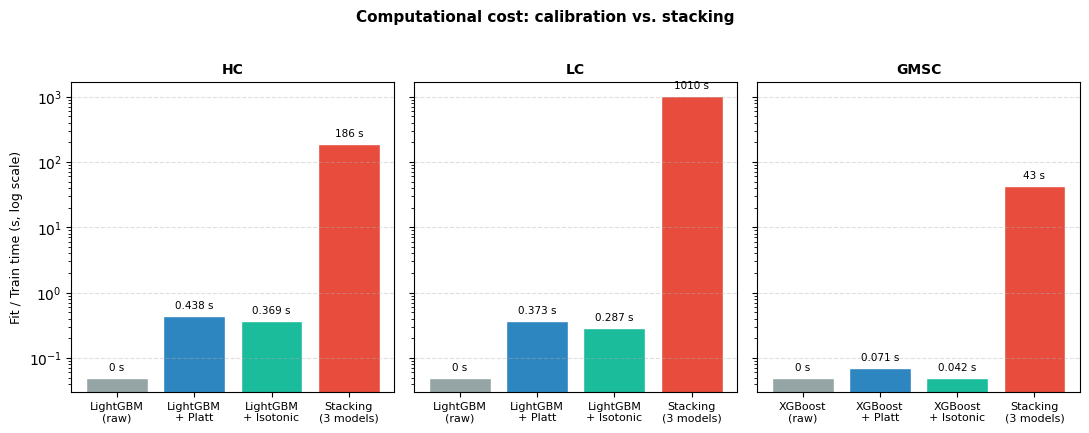

In [77]:
%matplotlib inline
import matplotlib.pyplot as plt
# ============================================================
# FIG. 1 — Computational cost: calibration vs. stacking
# Lay du lieu TRUC TIEP tu df_caltime_vs_stack_hc/lc/gmsc
# (da duoc tao san o cell A7/B7/C7 - Calibration, KHONG hardcode)
# FIX: model_labels doi theo tung dataset (LightGBM cho HC/LC, XGBoost cho GMSC)
#      thay vi hardcode "LightGBM" chung cho ca 3 subplot.
# ============================================================
plt.close('all')

caltime_tables = {
    "HC":   df_caltime_vs_stack_hc,
    "LC":   df_caltime_vs_stack_lc,
    "GMSC": df_caltime_vs_stack_gmsc,
}

# Ten model best-single dung rieng cho tung dataset (khop voi Table II)
best_single_by_tag = {
    "HC":   best_single_name_hc,
    "LC":   best_single_name_lc,
    "GMSC": best_single_name_gmsc,
}

def get_ordered_times(df_caltime):
    """Tra ve list [raw, Platt, Isotonic, Stacking] theo dung thu tu hien thi."""
    df = df_caltime.set_index('Model')['Fit time (s)']
    raw_key      = [k for k in df.index if 'raw' in k][0]
    platt_key    = [k for k in df.index if 'Platt' in k][0]
    isotonic_key = [k for k in df.index if 'Isotonic' in k][0]
    stack_key    = [k for k in df.index if 'Stacking' in k][0]
    return [df[raw_key], df[platt_key], df[isotonic_key], df[stack_key]]

times = {tag: get_ordered_times(df) for tag, df in caltime_tables.items()}

colors = ["#95A5A6", "#2E86C1", "#1ABC9C", "#E74C3C"]
floor = 0.05  # tranh log(0) cho cot raw = 0s

fig, axes = plt.subplots(1, 3, figsize=(11, 4.2), sharey=True)
for ax, (tag, vals_raw) in zip(axes, times.items()):
    vals = [max(v, floor) for v in vals_raw]
    bars = ax.bar(range(4), vals, color=colors, edgecolor="white")
    ax.set_yscale("log")
    ax.set_xticks(range(4))

    # FIX: label dung dung ten best-single model cua tung dataset
    base_model = best_single_by_tag[tag]
    model_labels = [f"{base_model}\n(raw)", f"{base_model}\n+ Platt",
                     f"{base_model}\n+ Isotonic", "Stacking\n(3 models)"]
    ax.set_xticklabels(model_labels, fontsize=8)

    ax.set_title(tag, fontsize=10, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for b, v, orig in zip(bars, vals, vals_raw):
        label = "0 s" if orig == 0 else (f"{orig:.0f} s" if orig >= 1 else f"{orig:.3f} s")
        ax.text(b.get_x() + b.get_width()/2, v*1.3, label, ha="center", fontsize=7.5)

axes[0].set_ylabel("Fit / Train time (s, log scale)", fontsize=9)
fig.suptitle("Computational cost: calibration vs. stacking", fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_time_cost.png", dpi=200, bbox_inches="tight")
plt.show()

In [80]:
# Xem cụ thể dòng nào có NaN ở các cột cần dùng
mask_nan = df_master_perf[colx].isna().any(axis=1)

print('TABLE VI - Calibration & cost summary: AUC, Brier and ECE')
col3 = ['Dataset', 'Model', 'Test AUC', 'Brier', 'ECE']
df_table_VI = df_master_perf[mask_nan][col3].copy()

# Đổi tên dataset sang viết tắt HC / LC / GMSC
dataset_rename = {
    'Home Credit': 'HC',
    'Lending Club': 'LC',
    'GiveMeSomeCredit': 'GMSC',
}
df_table_VI['Dataset'] = df_table_VI['Dataset'].replace(dataset_rename)

# Rút gọn tên Model: bỏ phần tên model gốc trước dấu "+", chỉ giữ Platt/Isotonic/Stacking/raw
# Vi du: "LightGBM + Platt" -> "Platt" ; "XGBoost + Isotonic" -> "Isotonic"
def short_model_name(m):
    if '+' in m:
        return m.split('+')[-1].strip()
    if 'Stacking' in m:
        return 'Stacking'
    return m  # truong hop "raw" giu nguyen

df_table_VI['Model'] = df_table_VI['Model'].apply(short_model_name)

# Gộp Dataset + Model thành 1 cột dạng "HC - Platt"
df_table_VI.insert(0, 'Dataset-Model', df_table_VI['Dataset'] + ' - ' + df_table_VI['Model'])
df_table_VI = df_table_VI.drop(columns=['Dataset', 'Model'])

df_table_VI

TABLE VI - Calibration & cost summary: AUC, Brier and ECE


,Dataset-Model,Test AUC,Brier,ECE
9,HC - Platt,0.7743,0.06691,0.0042
10,HC - Isotonic,0.7736,0.06681,0.0015
11,HC - Stacking,0.7770,0.06678,0.0041
21,LC - Platt,0.7029,0.16214,0.0132
22,LC - Isotonic,0.7026,0.16208,0.0054
23,LC - Stacking,0.7056,0.16241,0.0260
33,GMSC - Platt,0.8632,0.05041,0.0074
34,GMSC - Isotonic,0.8622,0.05021,0.0032
35,GMSC - Stacking,0.8625,0.05043,0.0055


In [81]:
# ============================================================
# BẢNG B — Expected Cost (thay Table VII + Table VIII)
# Cột: Dataset-Model | Cost @3:1 | Cost @5:1 | Cost @10:1 | Cost @15:1 | Saved % (@10:1)
# Bỏ Threshold/FN/FP ra khỏi bảng chính (để riêng ở Phụ lục nếu cần)
# ============================================================

# 1) Cost @ FN:FP = 10:1 -- gắn cột Dataset thủ công (hàm gốc không có sẵn)
df_cost_all = pd.concat([
    df_cost_hc.assign(Dataset='Home Credit'),
    df_cost_lc.assign(Dataset='Lending Club'),
    df_cost_gmsc.assign(Dataset='GiveMeSomeCredit'),
], ignore_index=True)

# 2) Cost ở 4 mức FN:FP (3/5/10/15) -- df_sens_all đã có sẵn cột Dataset, chỉ cần pivot
df_sens_wide = df_sens_all.pivot_table(
    index=['Dataset', 'Model'], columns='FN:FP ratio', values='Total cost'
).reset_index()
df_sens_wide.columns = ['Dataset', 'Model'] + [f'Cost @ {int(c)}:1' for c in df_sens_wide.columns[2:]]

# 3) Chỉ lấy cột % tiết kiệm từ df_cost_all (bỏ Threshold/FN/FP)
df_saved_pct = df_cost_all[['Dataset', 'Model', 'Cost saved vs worst (%)']].rename(
    columns={'Cost saved vs worst (%)': 'Saved % (@10:1)'})

# Gộp lại thành Bảng B
df_table_B_cost = df_sens_wide.merge(df_saved_pct, on=['Dataset', 'Model'], how='left')
df_table_B_cost = df_table_B_cost[[
    'Dataset', 'Model', 'Cost @ 3:1', 'Cost @ 5:1', 'Cost @ 10:1', 'Cost @ 15:1', 'Saved % (@10:1)'
]]

# ---- Đổi tên dataset sang viết tắt HC / LC / GMSC ----
dataset_rename = {
    'Home Credit': 'HC',
    'Lending Club': 'LC',
    'GiveMeSomeCredit': 'GMSC',
}
df_table_B_cost['Dataset'] = df_table_B_cost['Dataset'].replace(dataset_rename)

# ---- Rút gọn tên Model: bỏ tên model gốc trước dấu "+", chỉ giữ Platt/Isotonic/Stacking/raw ----
def short_model_name(m):
    if '+' in m:
        return m.split('+')[-1].strip()
    if 'Stacking' in m:
        return 'Stacking'
    return m  # truong hop "raw" giu nguyen

df_table_B_cost['Model'] = df_table_B_cost['Model'].apply(short_model_name)

# ---- Gộp Dataset + Model thành 1 cột dạng "HC - Platt" ----
df_table_B_cost.insert(0, 'Dataset-Model', df_table_B_cost['Dataset'] + ' - ' + df_table_B_cost['Model'])
df_table_B_cost = df_table_B_cost.drop(columns=['Dataset', 'Model'])

df_table_B_display = df_table_B_cost.round({
    'Cost @ 3:1': 0, 'Cost @ 5:1': 0, 'Cost @ 10:1': 0, 'Cost @ 15:1': 0, 'Saved % (@10:1)': 2,
})

print("=== BẢNG B — Expected Cost (thay Table VII + Table VIII) ===")
df_table_B_display

=== BẢNG B — Expected Cost (thay Table VII + Table VIII) ===


,Dataset-Model,Cost @ 3:1,Cost @ 5:1,Cost @ 10:1,Cost @ 15:1,Saved % (@10:1)
0,GMSC - Stacking,4653.0,6593.0,9989.0,12664.0,0.46
1,GMSC - XGBoost (raw),4660.0,6558.0,10032.0,12403.0,0.03
2,GMSC - Isotonic,4663.0,6558.0,10035.0,12554.0,0.00
3,GMSC - Platt,4671.0,6549.0,10022.0,12513.0,0.13
4,HC - LightGBM (raw),13591.0,20217.0,31401.0,37639.0,0.17
5,HC - Isotonic,13601.0,20273.0,31455.0,37627.0,0.00
6,HC - Platt,13584.0,20221.0,31381.0,37731.0,0.24
7,HC - Stacking,13625.0,20234.0,31299.0,37435.0,0.50
8,LC - LightGBM (raw),106082.0,128992.0,146085.0,150862.0,0.38
9,LC - Isotonic,105952.0,128863.0,146103.0,151164.0,0.37


In [62]:
print('=== TABLE IX — Ablation stacking gain vs. number of features (Home Credit) ===')
df_ablation_hc.to_excel('df9.xlsx')
df_ablation_hc

=== TABLE IX — Ablation stacking gain vs. number of features (Home Credit) ===


,n_features,Single AUC,Stacking AUC,Stacking gain (%)
0,455,0.7743,0.7770,0.353
1,200,0.7738,0.7758,0.261
2,100,0.7733,0.7742,0.116
3,50,0.7711,0.7715,0.046
4,20,0.7637,0.7636,-0.006
5,13,0.7565,0.7566,0.008
